# Análisis de Clustering RFM de Clientes de E-commerce

**Objetivo:**
  * Segmentar clientes en diferentes grupos basados en su comportamiento de compra utilizando el análisis RFM (Recency, Frequency, Monetary) y el algoritmo de clustering K-Means.
  * Enriquecer la clusterización anterior usando otras variables (e.j., categóricas) con otros algoritmos como K-Prototypes.
  * Segmentar clientes en base a la ubicación de su residencia en base al algoritmo DBSCAN.
  * Con esto se busca conocer mejor a los clientes y sus hábitos de compra, de cara a permitir que a la empresa dirigir estrategias de marketing más efectivas a cada segmento.

**Dataset**:
  * La información del dataset se encuentra aquí: https://www.kaggle.com/datasets/bytadit/transactional-ecommerce

### Tabla de Clientes
Contiene la información detallada de los usuarios registrados en la aplicación de comercio electrónico.

- **customer_id** = id único del cliente  
- **first_name** = nombre del cliente  
- **last_name** = apellido del cliente  
- **username** = nombre de usuario del cliente  
- **email** = correo electrónico del cliente  
- **gender** = género del cliente (Masculino (M) o Femenino (F))  
- **device_type** = tipo de dispositivo usado por el cliente al usar la app  
- **device_id** = id del dispositivo usado por el cliente en la app  
- **device_version** = versión detallada del dispositivo usado por el cliente  
- **home_location_lat** = latitud de la ubicación del cliente  
- **home_location_long** = longitud de la ubicación del cliente  
- **home_location** = provincia/región del cliente  
- **home_country** = país del cliente  
- **first_join_date** = fecha de registro inicial del cliente en la app  

---

### Tabla de Productos
Contiene los datos detallados de los productos (moda) vendidos en la aplicación.

- **id** = id del producto  
- **gender** = productos orientados/destinados según género  
- **masterCategory** = categoría principal del producto  
- **subCategory** = subcategoría del producto  
- **articleType** = tipo de producto de moda  
- **baseColour** = color base del producto de moda  
- **season** = productos orientados/destinados según temporada  
- **year** = año de producción  
- **usage** = tipo de uso del producto  
- **productDisplayName** = nombre de visualización del producto en la app  

---

### Tabla de Transacciones
Contiene los datos de cada transacción/pedido realizado por el cliente.  
Cada cliente puede hacer múltiples compras de múltiples productos.

- **created_at** = marca de tiempo en que se creó el dato/transacción  
- **customer_id** = id único de cada cliente  
- **booking_id** = id único de la transacción  
- **session_id** = id de sesión único del usuario al visitar la app  
- **product_metadata** = metadatos del producto comprado  
- **payment_method** = método de pago usado en la transacción  
- **payment_status** = estado del pago (Éxito / Fallido)  
- **promo_amount** = monto del descuento en cada transacción  
- **promo_code** = código promocional  
- **shipment_fee** = coste de envío de la transacción (ongkir)  
- **shipment_date_limit** = fecha límite de envío  
- **shipment_location_lat** = latitud de la ubicación/destino del envío  
- **shipment_location_long** = longitud de la ubicación/destino del envío  
- **total_amount** = monto total a pagar en cada transacción  


### Notas:
- Por simplicidad, no vamos a usar los datos de Click Stream

## 0. Carga de Librerías y Definir funciones comunes

In [ ]:
!pip install kmodes==0.12.2


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install --upgrade kaleido


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import ast
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from kmodes.kprototypes import KPrototypes
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

### 0.1 Funciones comunes

* Aquí puedes incluir las funciones comunes que uses en el código de cara a reutilizarlas cuando lo necesites.

He incluido en el notebook las funciones que muestra el profesor Guillermo durante la clase.

In [ ]:
def _elbow_k_by_max_distance(K_values, sse):
    """
    Detecta el 'codo' como el punto con máxima distancia perpendicular
    a la recta que une el primer y el último punto (K, SSE).

    Parámetros
    ----------
    K_values : list o array (n_k,)
    sse : list o array (n_k,)

    Retorna
    -------
    elbow_k : int
    distances : np.ndarray
        Distancias calculadas para cada K (útil para depurar/mostrar).
    """

    K = np.array(list(K_values), dtype=float)
    S = np.array(sse, dtype=float)

    # Puntos extremos
    x1, y1 = K[0], S[0]
    x2, y2 = K[-1], S[-1]

    # Vector de la recta
    line_vec = np.array([x2 - x1, y2 - y1], dtype=float)
    line_len = np.linalg.norm(line_vec)
    if line_len == 0:
        # Caso degenerado: SSE constante (muy raro)
        return int(K[0]), np.zeros_like(K)

    # Distancia de cada punto a la recta (fórmula de distancia punto-recta en 2D)
    # distancia = |(P - P1) x (P2 - P1)| / ||P2 - P1||
    # donde "x" es el producto cruzado en 2D (da un escalar)
    distances = []
    for xi, yi in zip(K, S):
        p_vec = np.array([xi - x1, yi - y1], dtype=float)
        cross = abs(p_vec[0] * line_vec[1] - p_vec[1] * line_vec[0])
        distances.append(cross / line_len)

    distances = np.array(distances)
    elbow_k = int(K[np.argmax(distances)])
    return elbow_k, distances

In [ ]:
def find_optimal_k(data, min_k=2, max_k=10, show_plot=True, random_state=42):
    """
    Encuentra el número óptimo de clusters (K) para K-Means usando:
      - Silhouette Score (máximo)
      - Elbow/Knee en la curva SSE (inercia) con detección automática

    Parámetros
    ----------
    data : array-like (n_samples, n_features)
        Dataset a clusterizar (idealmente escalado).

    min_k : int, default=2
        K mínimo a evaluar.

    max_k : int, default=10
        K máximo a evaluar.

    show_plot : bool, default=True
        Si True, muestra las gráficas de silueta y SSE con marcas de K óptimo.

    random_state : int, default=42
        Semilla para reproducibilidad en KMeans.

    Returns
    -------
    optimal_k_silhouette : int
        K que maximiza el silhouette score.

    optimal_k_elbow : int
        K detectado por el método del codo (knee) sobre la SSE.

    results : dict
        Diccionario con listas 'K', 'silhouette', 'sse' (útil para análisis extra).
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    for k in K_values:
        print(f"Training model for K={k}")
        kmeans_model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            algorithm="lloyd",
            random_state=random_state
        )

        kmeans_model.fit(data)
        labels = kmeans_model.labels_

        # Silhouette (solo tiene sentido con K>=2; aquí ya lo garantizamos)
        sil = silhouette_score(data, labels)
        silhouette_scores.append(sil)

        # SSE (inercia)
        sse.append(kmeans_model.inertia_)

    # K óptimo por silueta
    optimal_k_silhouette = list(K_values)[int(np.argmax(silhouette_scores))]

    # K óptimo por codo empleando la función definida previamente
    optimal_k_elbow, elbow_distances = _elbow_k_by_max_distance(K_values, sse)

    if show_plot:
        plt.figure(figsize=(12, 6))

        # Silueta
        plt.subplot(1, 2, 1)
        plt.plot(list(K_values), silhouette_scores, marker="o")
        plt.axvline(
            x=optimal_k_silhouette,
            color="r",
            linestyle="--",
            label=f"Óptimo Silueta: K={optimal_k_silhouette}"
        )

        plt.title("Silhouette Score vs K")
        plt.xlabel("Número de clusters (K)")
        plt.ylabel("Silhouette Score")
        plt.grid(True)
        plt.legend()

        # Codo (SSE)
        plt.subplot(1, 2, 2)
        plt.plot(list(K_values), sse, marker="o")
        plt.axvline(
            x=optimal_k_elbow,
            color="g",
            linestyle="--",
            label=f"Codo (knee): K={optimal_k_elbow}"
        )

        plt.title("Elbow Method (SSE/Inercia) vs K")
        plt.xlabel("Número de clusters (K)")
        plt.ylabel("SSE / Inercia (menor es mejor)")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    print(f"Optimal K by silhouette: {optimal_k_silhouette}")
    print(f"Optimal K by elbow: {optimal_k_elbow}")

    results = {
        "K": list(K_values),
        "silhouette": silhouette_scores,
        "sse": sse,
        "elbow_distances": elbow_distances.tolist(),
        "optimal_k_silhouette": optimal_k_silhouette,
        "optimal_k_elbow": optimal_k_elbow
    }

    return results

In [ ]:
def find_optimal_k_kprototypes_cost(
    data,
    cat_idx,
    min_k=2,
    max_k=10,
    n_jobs=-1,
    n_init=5,
    random_state=42,
    show_plot=True
):
    """
    Encuentra K óptimo para K-Prototypes usando:
      - coste (cost_) y detección automática del codo (knee)
    Devuelve un diccionario 'results'.

    Parámetros
    ----------
    data : array-like (n_samples, n_features)
        Dataset con variables mixtas (numéricas + categóricas).

    cat_idx : list[int]
        Índices de columnas categóricas en 'data'.

    min_k, max_k : int
        Rango de K a evaluar.

    n_jobs : int
        Paralelización vía joblib.

    n_init : int
        Número de inicializaciones del algoritmo.

    random_state : int
        Semilla para reproducibilidad.

    show_plot : bool
        Si True, muestra el gráfico de coste con el codo marcado.

    Returns
    -------
    results : dict con claves:
        - "K": lista de K evaluados
        - "cost": lista de costes (cost_) por K
        - "elbow_distances": lista de distancias (para depurar/visualizar)
        - "optimal_k_elbow": K detectado por el método del codo
    """

    K_values = list(range(min_k, max_k + 1))

    def evaluate_k(K):
        print(f"Training K-Prototypes for K={K}")
        kproto = KPrototypes(
            n_clusters=K,
            init="Huang",
            n_init=n_init,
            random_state=random_state
        )

        kproto.fit(data, categorical=cat_idx)
        return K, float(kproto.cost_)

    # Ejecuta en paralelo
    results_parallel = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_k)(K) for K in K_values
    )

    # Ordena por K por seguridad
    results_parallel = sorted(results_parallel, key=lambda x: x[0])

    Ks, costs = zip(*results_parallel)
    Ks = list(Ks)
    costs = list(costs)

    # Detecta el codo automáticamente (reutilizando la MISMA función)
    optimal_k_elbow, elbow_distances = _elbow_k_by_max_distance(Ks, costs)

    # Plot
    if show_plot:
        plt.figure(figsize=(7, 5))

        plt.plot(Ks, costs, marker="o")
        plt.axvline(
            x=optimal_k_elbow,
            color="g",
            linestyle="--",
            label=f"Codo (knee): K={optimal_k_elbow}"
        )

        plt.xlabel("Number of clusters (K)")
        plt.ylabel("Clustering cost (cost_)")
        plt.title("Elbow Method for K-Prototypes (cost_)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"Optimal K by elbow (K-Prototypes): {optimal_k_elbow}")

    results = {
        "K": Ks,
        "cost": costs,
        "elbow_distances": elbow_distances.tolist(),
        "optimal_k_elbow": optimal_k_elbow
    }

    return results

In [ ]:
def build_combined_distance_matrix(
    coords_deg,              # (n,2) en grados: [lat, lon]
    X_num_scaled,            # (n,p) numéricas ya escaladas
    eps_geo_km=1500.0,       # escala geo en km para normalizar
    eps_num=1.5,             # escala num en (z-score) para normalizar
    earth_radius_km=6371.0
):
    """
    D_total = sqrt( (D_geo_km/eps_geo_km)^2 + (D_num/eps_num)^2 )

    - D_geo_km: distancia Haversine en km (coords en radianes)
    - D_num: distancia euclídea en espacio numérico escalado
    """

    # Distancia numérica (euclídea)
    D_num = pairwise_distances(X_num_scaled, metric="euclidean")

    # Distancia geográfica Haversine:
    # haversine_distances espera radianes y devuelve distancia angular
    coords_rad = np.radians(coords_deg)
    D_geo_km = haversine_distances(coords_rad) * earth_radius_km

    # Combinar normalizando
    D = np.sqrt((D_geo_km / eps_geo_km) ** 2 + (D_num / eps_num) ** 2)

    return D, D_geo_km, D_num

In [ ]:
def k_distance_plot_from_precomputed(D, k, title=None, eps_line=None):
    """
    K-distance plot a partir de matriz de distancias precomputada D (n,n).
    - Ordena distancias por fila (incluye self=0)
    - Toma la distancia al k-ésimo vecino (índice k, porque índice 0 es self)
    - Ordena globalmente y grafica
    """

    D = np.asarray(D)
    if D.shape[0] != D.shape[1]:
        raise ValueError("D debe ser una matriz cuadrada (n,n).")

    D_sorted = np.sort(D, axis=1)
    kth_dist = D_sorted[:, k]      # vecino k (saltando self en 0)
    kth_sorted = np.sort(kth_dist) # orden global

    plt.figure(figsize=(8, 5))
    plt.plot(kth_sorted)

    if eps_line is not None:
        plt.axhline(eps_line, color="red", linestyle="--", label=f"eps={eps_line}")
        plt.legend()

    plt.xlabel("Puntos ordenados")
    plt.ylabel(f"Distancia al {k}-ésimo vecino (distancia combinada)")
    plt.title(title or f"K-distance plot (k={k})")
    plt.grid(True)
    plt.show()

    return kth_sorted

In [ ]:
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k_original(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Sum of Squared Distances')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

In [ ]:
def find_optimal_k_kprototypes(data, cat_idx: list, min_k=2, max_k=10, n_jobs=-1):
    """
    Finds the optimal number of clusters (K) for K-Prototypes clustering
    using silhouette scores and the elbow method. Parallelized with joblib.

    Parameters
    ----------
    data : array-like of shape (n_samples, n_features)
        The dataset to be clustered. Must contain both numerical and categorical features.
        Rows represent samples and columns represent features.

    cat_idx : list of int
        List of indices corresponding to categorical columns in `data`.

    min_k : int, optional (default=2)
        The minimum number of clusters (K) to evaluate.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to evaluate.

    n_jobs : int, optional (default=-1)
        Number of parallel jobs. -1 means using all available cores.

    Returns
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes
    -----
    - The silhouette score measures how well clusters are separated.
      A higher score indicates more cohesive and distinct clusters.
    - The elbow method is based on the K-Prototypes cost function (`cost_`),
      which is analogous to inertia in KMeans. It reflects the sum of
      dissimilarities (numerical + categorical) between points and their
      assigned cluster centroids.
    - The function produces two plots:
        * Silhouette Score vs. K values
        * Cost (inertia) vs. K values (Elbow Method)
    - Use both plots to determine the most meaningful K:
      the silhouette score identifies well-separated clusters,
      while the elbow plot helps detect diminishing returns.

    Example
    -------
    >>> optimal_k = find_optimal_k_kprototypes(data, cat_idx=[0, 2, 5], max_k=8)
    >>> print(optimal_k)
    4
    """

    def evaluate_k(K):
        """Train KPrototypes for a given K and compute silhouette + cost."""
        print(f"Training model for K={K}")
        kproto = KPrototypes(n_clusters=K, init='Huang', n_init=5, random_state=42)
        clusters = kproto.fit_predict(data, categorical=cat_idx)
        silhouette_avg = silhouette_score(data, clusters)
        return silhouette_avg, kproto.cost_

    # Run clustering in parallel for each K
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_k)(K) for K in range(min_k, max_k + 1)
    )

    # Unpack results
    silhouette_scores, sse = zip(*results)
    K_values = list(range(min_k, max_k + 1))

    # Find optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores (cost) for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Clustering Cost (Inertia)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

Aquí voy a modificar la función para calcular correctamente los valores en el parseado.

In [ ]:
#Función para parsear product_metadata
import ast

def parse_product_metadata(metadata_str):
    try:
        items = ast.literal_eval(metadata_str)

        product_ids = [item['product_id'] for item in items]

        total_quantity = sum(
            item['quantity'] for item in items
        )

        total_price = sum(
            item['quantity'] * item['item_price'] for item in items
        )

        num_items = len(set(product_ids))

        return product_ids, total_quantity, total_price, num_items

    except Exception as e:
        return [], 0, 0, 0

## Justificación metodológica de las funciones utilizadas

Para la selección del número óptimo de clústeres se han utilizado las funciones propuestas por el profesor Guillermo en lugar de las funciones inicialmente aportadas en el notebook base de la actividad. Esta decisión se ha tomado debido a la ventajas aportadas por esas funciones.

La función `find_optimal_k` nos permite comparar dos métodos complementarios para la selección de K, que son la puntuación silhouette y el método del codo. Además, la función `_elbow_k_by_max_distance` detecta el punto de máxima curvatura utilizando la distancia perpendicular máxima respecto a la recta formada entre el primer y el último punto de la curva SSE, por tanto quita la subjetividad asociada a la inspección visual de la gráfica a la hora de aplicar el método del codo.

Por otro lado, he prefirido usar la función `find_optimal_k_kprototypes_cost`, basada en el coste interno del modelo (`cost_`) y el método del codo, para el algoritmo K-Prototypes ya que trabaja con variables mixtas (numéricas y categóricas) utilizando una función de distancia híbrida. Por lo tanto, el uso directo de métricas como `silhouette_score` no me parece la mejor opción, ya que dicha métrica está principalmente diseñada para espacios métricos numéricos basados en distancias euclídeas.

## 1. Cargar datos

In [ ]:
# Cargamos los datos de transacciones, clientes y productos
# El archivo de productos no se usará directamente análisis como el de RFM, pero se carga para una exploración inicial

transactions = pd.read_csv('transactions.csv', quoting=1, on_bad_lines='skip')
customers = pd.read_csv('customer.csv')
products = pd.read_csv('product.csv', on_bad_lines='skip')
print('Datasets cargados correctamente.')
print(f'Transacciones: {transactions.shape}')
print(f'Clientes: {customers.shape}')
print(f'Productos: {products.shape}')

Datasets cargados correctamente.
Transacciones: (852584, 14)
Clientes: (100000, 15)
Productos: (44424, 10)


In [ ]:
print("================ Transactions ================")
display(transactions.head(2))
print("================ Customers ================")
display(customers.head(2))
print("================ Products ================")
display(products.head(2))

================ Transactions ================


,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526


================ Customers ================


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16


================ Products ================


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans


## 2. Preprocesamiento y Creación de Features RFM

He cambiado la función para parsear lo datos para obtener el precio total de los productos.

In [ ]:
%%time
# Procesamiento inicial
df = transactions.copy()
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Transacciones: {len(df):,}")

# Parsear metadata de productos
print("Parseando metadata de productos...")
parsed_data = df['product_metadata'].apply(lambda x: pd.Series(parse_product_metadata(x)))
df['product_ids']    = parsed_data[0]
df['total_quantity'] = parsed_data[1]
df['total_price']    = parsed_data[2]
df['num_items']      = parsed_data[3]

print("Parsing completado.")

Transacciones: 852,584
Parseando metadata de productos...
Parsing completado.
CPU times: total: 32.7 s
Wall time: 32.9 s


In [ ]:
print("================ Transacciones parseadas ================")
display(df.head(5))

================ Transacciones parseadas ================


,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount,product_ids,total_quantity,total_price,num_items
0,2018-07-29 15:22:01.458193+00:00,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832,[54728],1,191247,1
1,2018-07-30 12:40:22.365620+00:00,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526,[16193],1,145526,1
2,2018-09-15 11:51:17.365620+00:00,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18T08:41:49.422380Z,-2.579428,115.743885,550696,[53686],4,540696,1
3,2018-11-01 11:23:48.365620+00:00,4774,f5e530a7-4350-4cd1-a3bc-525b5037bcab,bcad5a61-1b67-448d-8ff4-781d67bc56e4,"[{'product_id': 20228, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-11-05T17:42:27.954235Z,-3.602334,120.363824,271012,[20228],1,271012,1
4,2018-12-18 11:20:30.365620+00:00,4774,0efc0594-dbbf-4f9a-b0b0-a488cfddf8a2,df1042ab-13e6-4072-b9d2-64a81974c51a,"[{'product_id': 55220, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-12-23T17:24:07.361785Z,-3.602334,120.363824,198753,[55220],1,198753,1


In [ ]:
#Guardo los datos en un csv
df.to_csv("transactions_parsed.csv", index=False, encoding="utf-8")

Una vez tengo las transacciones parseadas vamos a unirlas con la tabla de clientes. Uso un inner join pues  no nos interesa que haya transacciones sin clientes asociados para este estudio. Aunque para garantizar que no hay transacciones sin vincular a clientes vamos a comparar las dimensiones de las tablas al hacer el inner hoin y el left join.

In [ ]:
transaction_parsed=df.copy()

In [ ]:
df = transaction_parsed.merge(
    customers,
    on='customer_id',
    how='inner'
)

In [ ]:
#Guardo los datos en un csv
df.to_csv("transactions_clientes.csv", index=False, encoding="utf-8")

In [ ]:
df.shape

(852584, 32)

In [ ]:
df_left = transaction_parsed.merge(
    customers,
    on='customer_id',
    how='left'
)

In [ ]:
df_left.shape

(852584, 32)

Tienen la misma dimensión. Por lo que no hay transacciones sin asociar a clientes. Vamos a usar `df`. Borramos`df_left`:

In [ ]:
del df_left

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 852584 entries, 0 to 852583
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   created_at              852584 non-null  datetime64[us, UTC]
 1   customer_id             852584 non-null  int64              
 2   booking_id              852584 non-null  str                
 3   session_id              852584 non-null  str                
 4   product_metadata        852584 non-null  str                
 5   payment_method          852584 non-null  str                
 6   payment_status          852584 non-null  str                
 7   promo_amount            852584 non-null  int64              
 8   promo_code              326536 non-null  str                
 9   shipment_fee            852584 non-null  int64              
 10  shipment_date_limit     852584 non-null  str                
 11  shipment_location_lat   852584 non-nu

#### PREGUNTA 1:
* ¿Cómo calculamos las variables RFM en base a los datos disponibles?

#### RESPUESTA:
Para calcular las variables RMF primero vamos a entender que son estas variables. Las variables RFM hacen referencia a R de "Recency", F de "Frecuency" y M de "Monetary". "Recency" son los días o el intervalo de tiempo que han pasado desde la última compra del cliente, "Frecuency" representa el número total de transacciones realizadas por el cliente dentro de la ventana temporal observada en el dataset y "Monetary" es el dinero total gastado por el cliente.

Vamos a comenzar tomando la fecha más reciente de nuestro dataset y sumarle un día, eso es lo que consideraremos como fecha de referencia. Despúes restaremos la fecha de refrencia menos la fecha máxima para cada cliente y de esta forma obtendremos la "Recency". Al sumar un día a la fecha máxima de nuestro dataset evitamos que nos salga una R igual a cero.

Para calcular la frecuencia vamos a usar el campo `booking_id` que es el que identifica univocamente una transacción. Por tanto, contando los diferentes `booking_id`que tenemos para cada cliente en nuestros datos parseados, obtenemos el número de transacciones realizadas por nuestro cliente en el tiempo de estudio. Podemos hacer también una métrica que muestre mejor la actividad de un cliente, ya que la métrica de frecuencia que hemos dicho no diferencia entre clientes que llevan poco tiempo y los que llevan mucho. Para ello podemos coger el campo `first_join_date` y restárselo a la fecha de referencia para ver cuanto tiempo lleva nuestro cliente. Con esto podemos el número de transacciones echas por nuestro cliente y el número de meses que lleva para ver las compras medias que ha hecho por mes. Aunque esta métrica puede verse afectada por clientes de muy reciente incorporación, cuyos ratios de actividad pueden resultar artificialmente elevados debido a una ventana temporal reducida. Por lo que luego ya valoraremos si es mejor prescindir de ella.

También podriamos crear otra métrica que nos permitiera caracterizar cómo se distribuyen las compras entre distintas sesiones registradas, para ello contariamos el número de sesiones `session_id` para cada cliente y dividiríamos el número de transacciones entre el de sesiones.

Para el cálculo de M podemos calcular el gasto total realizado por cada cliente sumando los valores del campo `total_amount` para cada cliente diferente, siempre y cuando el `payment_status` sea de "Success".

Con las modificaciones que hemos hecho para parsear los datos tenemos el valor total de los productos en `total_price`, por lo que podríamos obtener también `total_amount` como:
`total_amount` = `total_price` + `shipment_fee` - `promo_amount`

Y de esta manera podemos comprobar que los valores de `total_amount` son correctos.

En conclusión, como solo nos interesan las transacciones exitosas calcularemos las RFM quitando las no exitosas del dataset.

In [ ]:
#Realizo copia de seguridad
rfm_df = df.copy()

#Paso fechas que faltan a date_time
rfm_df['created_at'] = pd.to_datetime(rfm_df['created_at'])
rfm_df['first_join_date'] = pd.to_datetime(rfm_df['first_join_date']).dt.tz_localize('UTC')

#Cogemos solo las transacciones exitosas

rfm_df = rfm_df[
    rfm_df['payment_status'] == 'Success'
].copy()

print(f"Transacciones exitosas: {len(rfm_df):,}")

#Creo la fecha de referencia

reference_date = (
    rfm_df['created_at'].max() + pd.Timedelta(days=1)
)

print(f"Fecha de referencia: {reference_date}")

#Compruebo que el total_amount sea correcto

rfm_df['calculated_total_amount'] = (
    rfm_df['total_price']
    + rfm_df['shipment_fee']
    - rfm_df['promo_amount']
)

#Creo un campo que indica si es correcto
rfm_df['is_amount_difference'] = (
    rfm_df['total_amount']
    != rfm_df['calculated_total_amount']
).astype(int)

print("\nComprobación del cálculo de total_amount:")
display(
    rfm_df[
        [
            'total_price',
            'shipment_fee',
            'promo_amount',
            'total_amount',
            'calculated_total_amount',
            'is_amount_difference'
        ]
    ].head()
)


Transacciones exitosas: 815,964
Fecha de referencia: 2022-08-01 23:59:19.821469+00:00

Comprobación del cálculo de total_amount:


,total_price,shipment_fee,promo_amount,total_amount,calculated_total_amount,is_amount_difference
0,191247,10000,1415,199832,199832,0
1,145526,10000,0,155526,155526,0
2,540696,10000,0,550696,550696,0
3,271012,0,0,271012,271012,0
4,198753,0,0,198753,198753,0


In [ ]:
#compruebo si hay diferentes
rfm_df['is_amount_difference'].sum()

np.int64(0)

In [ ]:
#Como no hay diferentes puedo eliminar el campo calculated_total_amount y el is_amount_difference
rfm_df = rfm_df.drop(
    columns=[
        'calculated_total_amount',
        'is_amount_difference'
    ]
)

In [ ]:
#Calculo las variable RFM
rfm = rfm_df.groupby('customer_id').agg({

    #calculo Recency
    'created_at': lambda x: (
        reference_date - x.max()
    ).days,

    #Calculo Frecuency
    'booking_id': 'nunique',

    #Calculo el gasto total por cliente
    'total_amount': 'sum',

    #Calculo el número de sesiones únicas por cliente
    'session_id': 'nunique',

    #Calculo la fecha de alta
    'first_join_date': 'min' #solo debería haber una pero por si acaso cojo la mínima

}).reset_index()

#Cambio el nombre de las columnas
rfm.columns = [
    'customer_id',
    'recency',
    'frequency',
    'monetary',
    'num_sessions',
    'first_join_date'
]

#Cálculo las métricas adicionales que he mencionado

#Tiempo que lleva el cliente en la plataforma

rfm['customer_lifetime_days'] = (
    reference_date - rfm['first_join_date']
).dt.days

rfm['customer_lifetime_months'] = (
    rfm['customer_lifetime_days'] / 30
)

#Compras medias del cliente por mes

rfm['transactions_per_month'] = (
    rfm['frequency']
    / rfm['customer_lifetime_months']
)

#Transacciones realizadas por sesión

rfm['transactions_per_session'] = (
    rfm['frequency']
    / rfm['num_sessions']
)

In [ ]:
#vemos la tabla final
print("\nDataset RFM generado correctamente.\n")

rfm.head()


Dataset RFM generado correctamente.



,customer_id,recency,frequency,monetary,num_sessions,first_join_date,customer_lifetime_days,customer_lifetime_months,transactions_per_month,transactions_per_session
0,3,36,49,20891374,49,2018-08-25 00:00:00+00:00,1437,47.900000,1.022965,1.0
1,8,78,7,3898561,7,2021-02-13 00:00:00+00:00,534,17.800000,0.393258,1.0
2,9,65,6,2638665,6,2021-06-26 00:00:00+00:00,401,13.366667,0.448878,1.0
3,11,147,1,197533,1,2022-03-06 00:00:00+00:00,148,4.933333,0.202703,1.0
4,15,208,5,2134870,5,2019-09-28 00:00:00+00:00,1038,34.600000,0.144509,1.0


In [ ]:
rfm.to_csv("RFM_variables.csv", index=False, encoding="utf-8")

In [ ]:
print("\nResumen estadístico:")
rfm.describe()


Resumen estadístico:


,customer_id,recency,frequency,monetary,num_sessions,customer_lifetime_days,customer_lifetime_months,transactions_per_month,transactions_per_session
count,50242.000000,50242.000000,50242.000000,5.024200e+04,50242.000000,50242.000000,50242.000000,50242.000000,50242.0
mean,49816.004259,300.604853,16.240675,8.936691e+06,16.240675,983.041599,32.768053,1.221538,1.0
std,28946.354892,434.430234,28.663494,1.608760e+07,28.663494,620.117134,20.670571,12.452689,0.0
min,3.000000,1.000000,1.000000,2.745000e+04,1.000000,1.000000,0.033333,0.013495,1.0
25%,24706.500000,40.000000,2.000000,7.734435e+05,2.000000,419.000000,13.966667,0.081967,1.0
50%,49742.500000,112.000000,6.000000,3.010699e+06,6.000000,916.000000,30.533333,0.261464,1.0
75%,74844.250000,362.000000,17.000000,9.832861e+06,17.000000,1485.000000,49.500000,0.796156,1.0
max,99999.000000,2222.000000,550.000000,3.200618e+08,550.000000,2223.000000,74.100000,1230.000000,1.0


#### PREGUNTA 2:
* Realiza un análisis exploratorio de datos de las variables RFM. ¿Es necesario realizar alguna transformación sobre ellas para usarlas en clustering?

#### Respuesta

Para ello primero vamos a hacer histogramas de barras de cada una de las variables y así estudiar como es la distribución de cada variable.

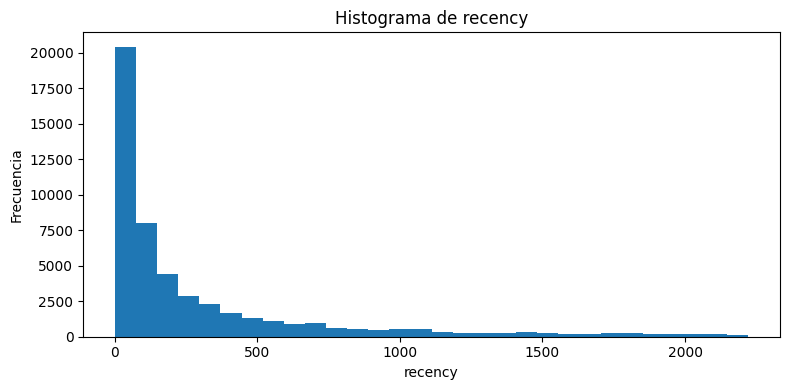

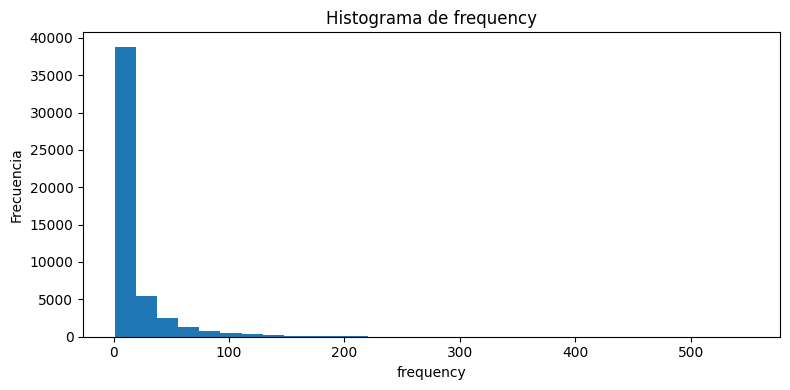

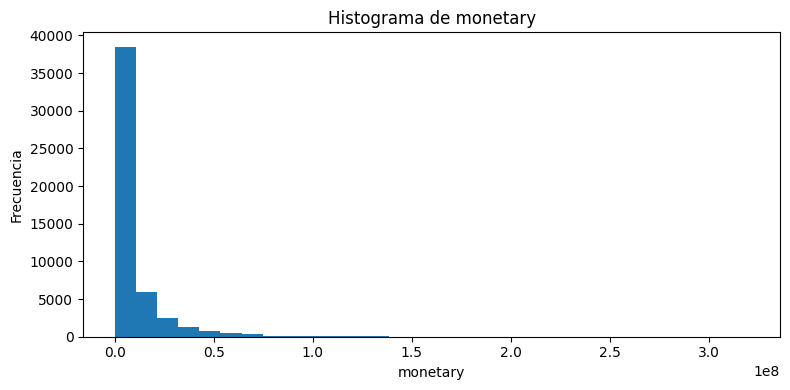

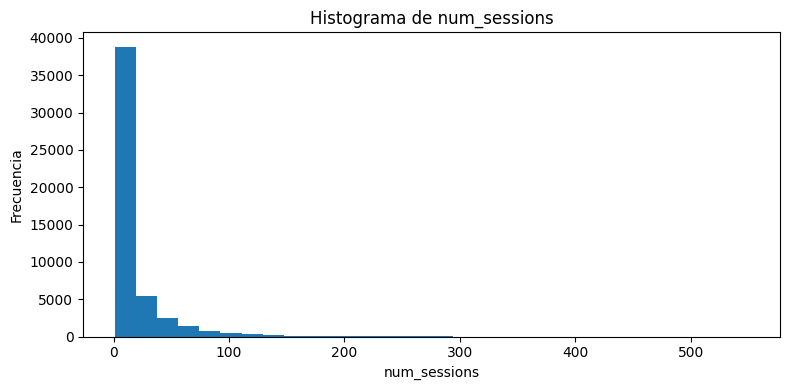

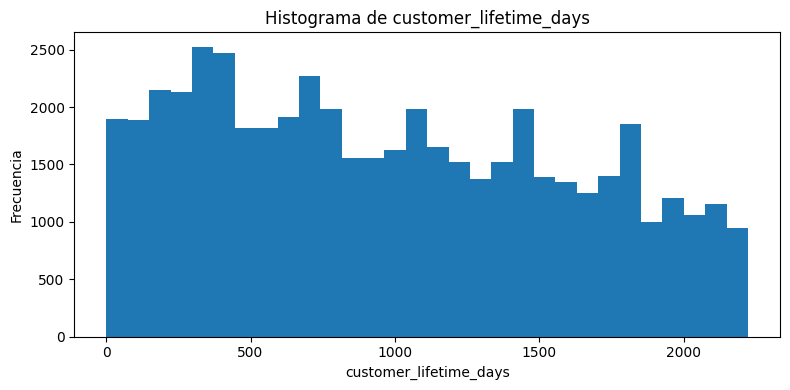

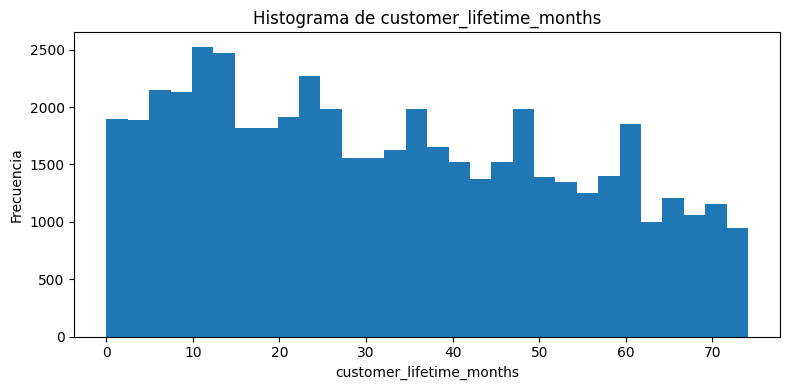

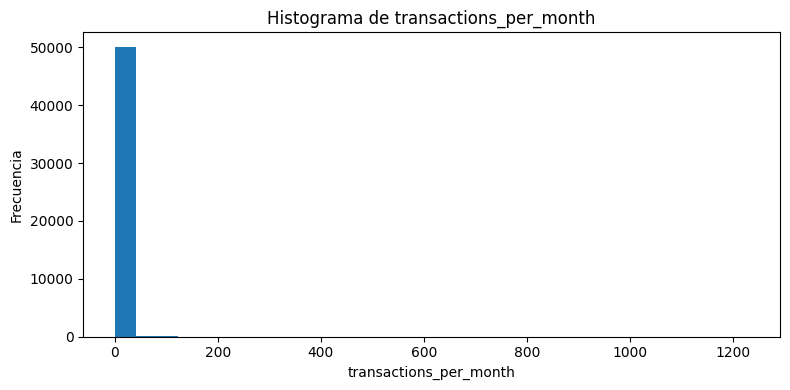

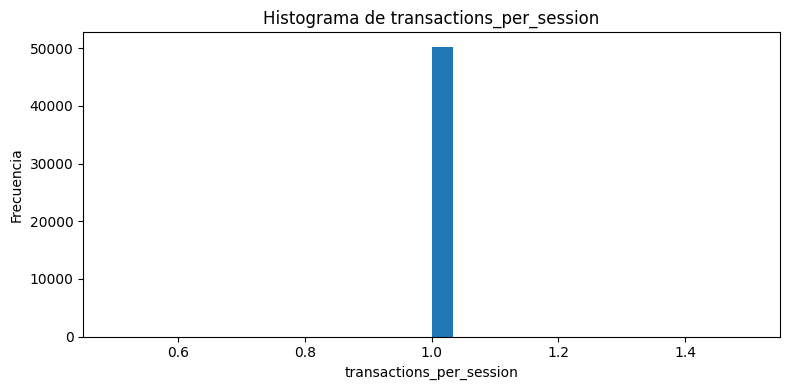

In [ ]:
columns = [
    'recency',
    'frequency',
    'monetary',
    'num_sessions',
    'customer_lifetime_days',
    'customer_lifetime_months',
    'transactions_per_month',
    'transactions_per_session'
]

# Crear gráficos
for col in columns:

    plt.figure(figsize=(8, 4))

    plt.hist(
        rfm[col],
        bins=30
    )

    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

Podemos ver que los histogramas de las variables `recency`, `frecuency`, `monetary` y `num_sessions` presentan distribuciones de cola larga, por lo que vamos a aplicar una transformación logaritmica para reducir las colas.

Vemos que las distribuciones de los histogramas de `customer_lifetime_months` y `customer_lifetime_days` tiene la misma forma pero cambia la escala del eje X, lo cual tiene sentido pues una magnitud es proporcional a la otra. Aunque hemos hecho las dos para obtener otras métricas solo nos interesa una de ellas y como luego haremos un Standar Scaler para que no influyan las magnitudes nos da igual cual de las dos elijamos.

También podemos ver que la distribución de la variable `transactions_per_month` presenta un pico muy predominate. También vamos a aplicarle la transformación logarítmica a ver como queda el resultado.

Por último, se decidió prescindir de la variable `transactions_per_session`, ya que su distribución muestra valores prácticamente constantes e iguales a 1 para la mayoría de los registros y, debido a su baja variabilidad, no aporta capacidad discriminativa relevante para el proceso de clustering. Esto indica que en nuestros datos las transacciones suelen estar asociadas a sesiones únicas o que únicamente se registran sesiones en las que se produce una compra.

In [ ]:
import numpy as np

log_columns = [
    'recency',
    'frequency',
    'monetary',
    'num_sessions',
    'transactions_per_month'
]

for col in log_columns:

    rfm[f'log_{col}'] = np.log1p(rfm[col])

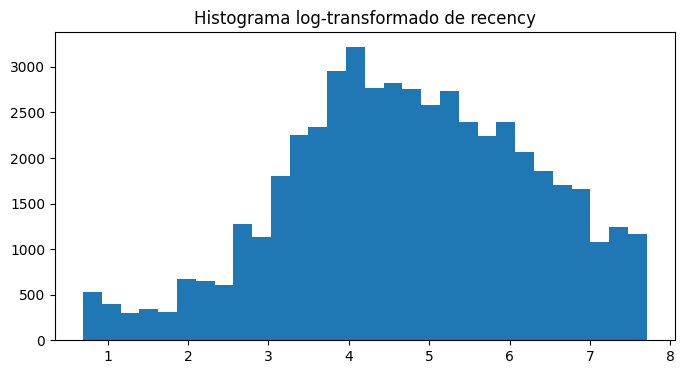

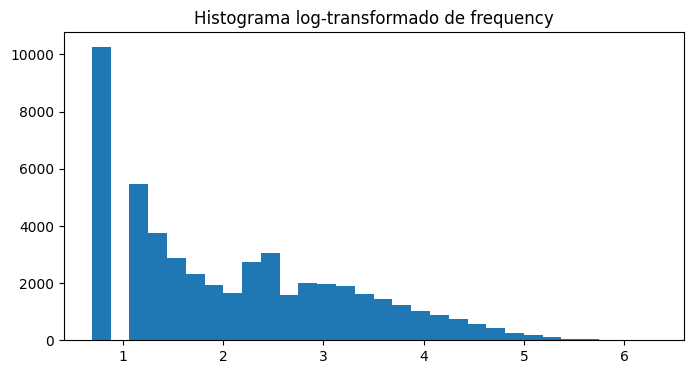

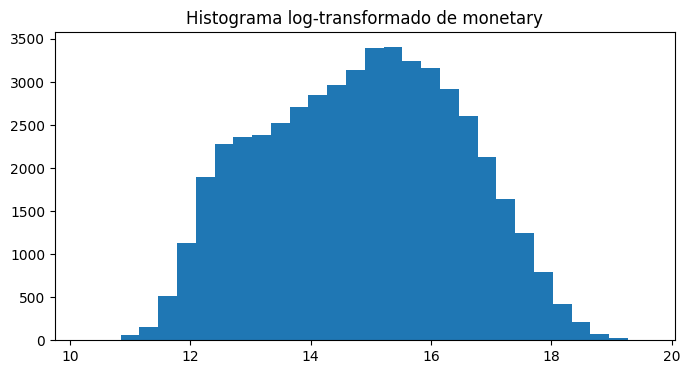

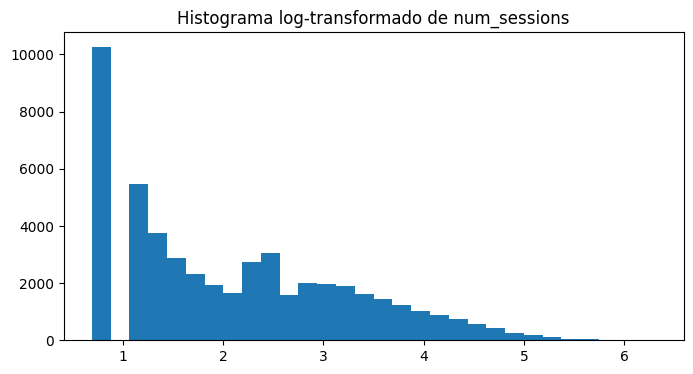

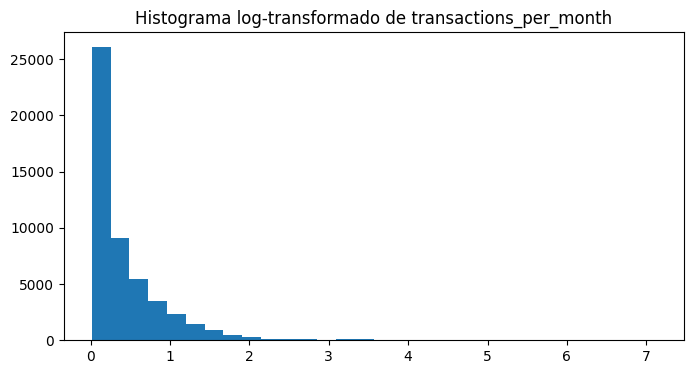

In [ ]:
for col in log_columns:

    plt.figure(figsize=(8,4))

    plt.hist(
        rfm[f'log_{col}'],
        bins=30
    )

    plt.title(f'Histograma log-transformado de {col}')

    plt.show()

Tiene sentido que las distribuciones de `frequency` y `num_sesiones` sean iguale spues ya hemos visto que el factor de proporcionalidad entre ambas era un valor fijo de 1. Por lo tanto vamos a prescindir de `num_sesiones`.

En cuanto a `transactions_per_month`, aunque la transformación logarítmica reduce parcialmente la asimetría de la distribución, sigue observándose una fuerte concentración de valores bajos y una cola larga pronunciada. Además debemos tener en cuenta que esta métrica puede verse fuertemente influenciada por clientes con poca antigüedad en la plataforma, generando ratios artificialmente elevados. Por estos motivos, decido no utilizar esta variable en el proceso final de clustering.

Por tanto las variables con las que me quedo finalmente son `recency`, `frequency` y `monetary`, las variables originales de RMF. Voy a prescindir finalmente de `customer_lifetime_month` ya que su función era que fuera una variable intermedia para la obtención de otra métrica como las `transactions_per_month`.

A continuación, realizo un Standar Scaler para que los órdenes de magnitud no interfieran en la clusterización.

In [ ]:
rfm_features = [
    'log_recency',
    'log_frequency',
    'log_monetary'
]

scaler = StandardScaler()

#Escalamos
rfm[rfm_features] = scaler.fit_transform(
    rfm[rfm_features]
)

#Conservamos únicamente el customer_id y las variables escaladas
rfm_scaled = rfm[
    ['customer_id'] + rfm_features
]


In [ ]:
rfm_og = rfm[["recency", "frequency", "monetary"]].copy()

## 3. Clustering con K-Means

#### PREGUNTA 3:
* Realiza una clusterización con K-Means sobre los datos de RFM calculados previamente

#### RESPUESTA:

Training model for K=2
Training model for K=3
Training model for K=4
Training model for K=5
Training model for K=6
Training model for K=7
Training model for K=8
Training model for K=9
Training model for K=10


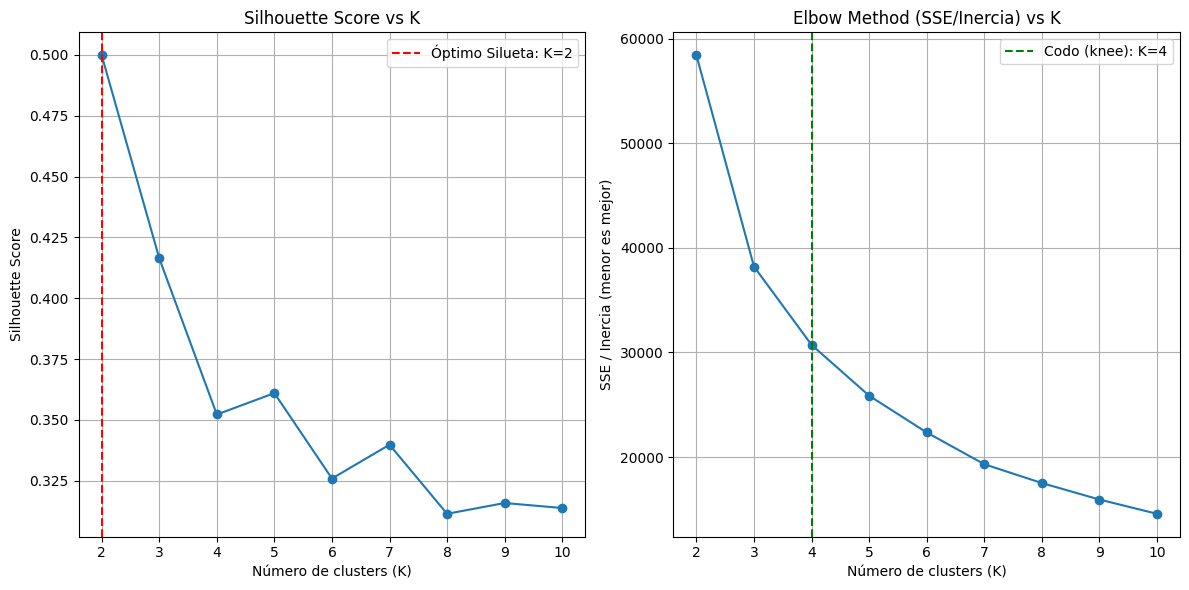

Optimal K by silhouette: 2
Optimal K by elbow: 4


In [ ]:
#Hago mi dataset para clusterización
X = rfm_scaled.drop(columns=['customer_id'])

#Busco el K óptimo con la función definida al principio
results = find_optimal_k(X)

Como me han salido dos K diferentes vamos a hacer un cluster con cada uno y a comparar los resultados que obtengamos.

In [ ]:
optimal_k_silhouette = results["optimal_k_silhouette"]
km_silhouette = KMeans(n_clusters=optimal_k_silhouette)
km_silhouette.fit(X)

optimal_k_elbow = results["optimal_k_elbow"]
km_elbow = KMeans(n_clusters=optimal_k_elbow)
km_elbow.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
df_cluster_num_scaled = pd.DataFrame(X, columns=rfm_features)
df_cluster_num_scaled["silhouette_labels"] = km_silhouette.labels_
df_cluster_num_scaled["elbow_labels"] = km_elbow.labels_

df_cluster_num = rfm_og.copy()
df_cluster_num["silhouette_labels"] = km_silhouette.labels_
df_cluster_num["elbow_labels"] = km_elbow.labels_

In [ ]:
df_cluster_num

,recency,frequency,monetary,silhouette_labels,elbow_labels
0,36,49,20891374,0,1
1,78,7,3898561,0,3
2,65,6,2638665,0,0
3,147,1,197533,1,2
4,208,5,2134870,1,0
...,...,...,...,...,...
50237,68,12,4352229,0,3
50238,3,59,31437103,0,1
50239,828,1,226461,1,2
50240,188,8,6692540,0,3


In [ ]:
df_cluster_num_scaled

,log_recency,log_frequency,log_monetary,silhouette_labels,elbow_labels
0,-0.742390,1.566900,1.228804,0,1
1,-0.243696,-0.004668,0.199389,0,3
2,-0.361900,-0.119180,-0.039968,0,0
3,0.169027,-1.193513,-1.629484,1,2
4,0.395926,-0.251376,-0.169888,1,0
...,...,...,...,...,...
50237,-0.332676,0.411689,0.266891,0,3
50238,-2.204964,1.723254,1.479394,0,1
50239,1.301815,-1.193513,-1.545679,1,2
50240,0.329796,0.096339,0.530759,0,3


#### PREGUNTA 4:
* ¿Qué interpretación haces de los resultados obtenidos con la clusterización? ¿Qué acciones propondrías hacer sobre ellos?

#### RESPUESTA:

A continuación muestro los resultados obtenidos con el método de la silueta.

In [ ]:
label = "silhouette_labels"

clusters = pd.DataFrame(df_cluster_num_scaled[rfm_features + [label]])
polar = clusters.groupby(label).mean().reset_index()
polar = pd.melt(polar, id_vars=[label])

fig_k_means_2 = px.line_polar(
    polar,
    r="value",
    theta="variable",
    color="silhouette_labels",
    line_close=True,
    height=800,
    width=600
)

fig_k_means_2.show()
fig_k_means_2.write_image("fig_k_means_2.png")

cluster_summary = (
    df_cluster_num.groupby(label)[rfm_og.columns.tolist()]
    .mean()
    .round(2)
)

cluster_summary["Count"] = df_cluster_num[label].value_counts()

print("Summary:")
display(cluster_summary)

Summary:


,recency,frequency,monetary,Count
silhouette_labels,,,,
0,52.14,31.52,17501902.72,23601
1,520.72,2.70,1348854.70,26641


Recordar que tal y como hemos definido `recency` valores más elevados indican clientes menos recientes y, por tanto, menor actividad reciente. Por lo tanto desde un punto de vista de negocio cuanto mayor sea este valor es peor pues tenemos clientes que hace mucho tiempo que no compran.

Por lo tanto de esta clusterización con k=2 hemos obtenido un grupo que engloba a usuarios que hace mucho que no compran, que compran poco y que gastan poco (clúster 1) y otro de clientes que ha comprado recientemente, con frecuencia alta y que además gasta bastante (clúster 0).

Por tanto, desde una perspectiva de negocio estaríamos dividiendo los clientes en clientes inactivos o de bajo valor y clientes activos o de alto valor. Sin embargo la considero una aproximación demasiado vaga a un entorno de e-commerce, en el que es interesante separar más tipos de usuarios. Por tanto, aunque la solución de dos clusters presenta una buena separación estadística según las métricas utilizadas, podría no ser la segmentación más útil desde el punto de vista operativo o estratégico del negocio.

A continuación muestro los resultados obtenidos con el método del codo.

In [ ]:
label = "elbow_labels"

clusters = pd.DataFrame(df_cluster_num_scaled[rfm_features + [label]])
polar = clusters.groupby(label).mean().reset_index()
polar = pd.melt(polar, id_vars=[label])

fig_k_means_4 = px.line_polar(
    polar,
    r="value",
    theta="variable",
    color=label,
    line_close=True,
    height=800,
    width=600
)

fig_k_means_4.show()
fig_k_means_4.write_image("fig_k_means_4.png")

cluster_summary = (
    df_cluster_num.groupby(label)[rfm_og.columns.tolist()]
    .mean()
    .round(2)
)

cluster_summary["Count"] = df_cluster_num[label].value_counts()

print("Summary:")
display(cluster_summary)

Summary:


,recency,frequency,monetary,Count
elbow_labels,,,,
0,219.66,4.01,2144680.90,14123
1,26.58,59.33,32954999.79,9370
2,845.65,1.33,521856.04,12771
3,68.10,13.34,7386961.24,13978


Podemos ver que tendríamos un clúster formado por los clientes que hace mucho que no compran, apenas realizaron compras y presentan bajo gasto acumulado (clúster 2) que podría representar usuarios perdidos, inactivos o de muy baja fidelización. Otro clúster estaría formado por los clientes con una actividad moderada, que realiza compras ocasionales y con un gasto medio bajo (clúster 0) que podría representar usuarios esporádicos o estacionales. El tercer grupo que diferenciaríamos sería el de clientes que han comprado hace relativamente poco, que compran con una recurrencia elevada y con un gasto significativo, reflejando clientes fieles o habituales (clúster 3). Por último distinguiríamos el grupo formado por los clientes con una actividad muy reciente, extremadamente recurrentes y con un gasto muy elevado, reflejando clientes que proablemente generan gran parte de los ingresos (clúster 1), y que desde una perspectiva de negocio serían prioritarios para fidelización, campañas premium, etc.

Por lo tanto, he decidido seleccionar la solución K=4 obtenida mediante el método del codo. Aunque el método de la silueta favorecía una segmentación más simple con dos clústeres, la solución de cuatro grupos proporciona una segmentación considerablemente interpretable desde el punto de vista de negocio, permitiendo identificar perfiles de clientes claramente diferenciados y potencialmente accionables dentro de un entorno de e-commerce.

Además, esta segmentación nos permite aplicar estrategias diferentes según el grupo del cliente. En el caso de los usuarios inactivos o de baja fidelización (clúster 2) podríamos aplicar campañas de reactivación mediante descuentos, promociones específicas o recordatorios personalizados para así recuperarlos. Sobre los clientes ocasionales (clúster 0) podríamos desarrollar estrategias destinadas a aumentar la frecuencia de compra, como serían las recomendaciones personalizadas, promociones temporales o programas de puntos. Para los clientes fieles (clúster 3), podríamos reforzar la fidelización mediante ventajas exclusivas, atención preferente o campañas adaptadas a sus hábitos de consumo. Finalmente, sobre los clientes VIP (clúster 1) podríamos aplicar estrategias orientadas a maximizar la retención y el valor del cliente, incluyendo programas VIP, acceso prioritario a productos, recomendaciones avanzadas o promociones exclusivas.

## 4. Consideración de variables adicionales sobre los clientes

In [ ]:
# Procesamiento de variables asociadas a los clientes
max_join_date = str(customers['first_join_date'].max())
print(max_join_date)
customers['first_join_date'] = pd.to_datetime(customers['first_join_date'])
customers['age'] = int(max_join_date[:4]) - pd.to_datetime(customers['birthdate']).dt.year

# Tiempo que un cliente ha permanecido activo con la empresa desde la fecha en que se unió por primera vez.
customers['tenure_days'] = (pd.to_datetime(max_join_date) - customers['first_join_date']).dt.days
display(customers.head(2))

2022-07-31


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date,age,tenure_days
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21,26,1106
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16,29,1841


#### PREGUNTA 5:
* Realiza un análisis exploratorio de las demás variables de clientes, y relaciónalas con la tabla de transacciones.
* ¿Es necesario realizar algún tipo de transformación sobre estas nuevas variables para hacer clustering con ellas?

#### RESPUESTA:

Vamos a volver a unir la tabla de trasacciones parseadas con la nueva tabla de clientes con los nuevos campos que se han creado en este apartado. Pero antes vamos a hacer una exploración inicial de los campos que hay presentes en la tabla clientes para saber que campos pueden ser interesantes para nuestro análisis.

In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   customer_id         100000 non-null  int64         
 1   first_name          100000 non-null  str           
 2   last_name           100000 non-null  str           
 3   username            100000 non-null  str           
 4   email               100000 non-null  str           
 5   gender              100000 non-null  str           
 6   birthdate           100000 non-null  str           
 7   device_type         100000 non-null  str           
 8   device_id           100000 non-null  str           
 9   device_version      100000 non-null  str           
 10  home_location_lat   100000 non-null  float64       
 11  home_location_long  100000 non-null  float64       
 12  home_location       100000 non-null  str           
 13  home_country        100000 non-null  str 

Vemos campos identificativos del usuario que a nosotros no nos aportan para la clasificación, como sería el nombre, los apellidos, el nombre de usuario o el email. Por lo tanto vamos a quitar esos campos.

In [ ]:
customers_to_cluster = customers.drop(columns=['first_name', 'last_name', 'username', 'email'])

Una vez habiendo calculado la edad aproximada del usuario ya la fecha de cumpleaños no nos sirve, así que la quitamos tambien. De igual manera, ya no necesitamos `first_join_date`ya que tenemos `tenure_days`.

In [ ]:
customers_to_cluster = customers_to_cluster.drop(columns=['birthdate', 'first_join_date'])

Vemos un ejemplo de los datos de la tabla:

In [ ]:
customers_to_cluster.head(4)

,customer_id,gender,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,age,tenure_days
0,2870,F,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,26,1106
1,8193,F,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,29,1841
2,7279,M,iOS,d13dde0a-6ae1-43c3-83a7-11bbb922730b,iPad; CPU iPad OS 4_2_1 like Mac OS X,-8.631607,116.428436,Nusa Tenggara Barat,Indonesia,33,707
3,88813,M,iOS,f4c18515-c5be-419f-8142-f037be47c9cd,iPad; CPU iPad OS 14_2 like Mac OS X,1.299332,115.774934,Kalimantan Timur,Indonesia,31,301


El campo `device_id` es un campo para identificar el dispositivo con el que el usuario hizo la transacción. Con él podríamos ver si un usuario tiene múltiples dispositivos, pero no lo considero algo prioritario así que vamos a prescindir de ese campo.Tampoco considero importante el `device_version` ya que, aunque podría usarse para estudiar posibles relaciones entre el nivel tecnológico del dispositivo y el comportamiento de compra de los usuarios, considero que aportaría más ruido que información relevante al modelo. También voy a prescindir de las variables de longitud y altitud, ya que para una segmentación general de clientes resulta más útil trabajar con variables categóricas más interpretables como la localización o el país. Las coordenadas geográficas podrían resultar más adecuadas en análisis específicamente orientados a clustering geoespacial que haremos más adelante, por lo que vamos a guardarlas en otra variable `coord_geo`.

In [ ]:
coord_geo_id=customers_to_cluster[['customer_id', 'home_location_lat','home_location_long']].copy()
customers_to_cluster = customers_to_cluster.drop(columns=['device_id', 'device_version', 'home_location_lat', 'home_location_long'])

In [ ]:
customers_to_cluster.head(4)

,customer_id,gender,device_type,home_location,home_country,age,tenure_days
0,2870,F,iOS,Sumatera Barat,Indonesia,26,1106
1,8193,F,Android,Jakarta Raya,Indonesia,29,1841
2,7279,M,iOS,Nusa Tenggara Barat,Indonesia,33,707
3,88813,M,iOS,Kalimantan Timur,Indonesia,31,301


Como el objetivo es describir comportamientos de compra vamos a vincular la tabla de variables RFM que obtuvimos de las transacciones con la nueva tabla de customers:

In [ ]:
rfm_scaled_customers = rfm_scaled.merge(
    customers_to_cluster,
    on='customer_id',
    how='inner'
)

Vamos a crear el conjunto con las variables sin escalar para cuando hagamos el resumen de resultados más adelante:

In [ ]:
rfm_og_id = rfm[["customer_id", "recency", "frequency", "monetary"]].copy()

In [ ]:
rfm_og_prototypes_id= rfm_og_id.merge(
    customers_to_cluster,
    on='customer_id',
    how='inner'
)

In [ ]:
rfm_scaled_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 50242 entries, 0 to 50241
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    50242 non-null  int64  
 1   log_recency    50242 non-null  float64
 2   log_frequency  50242 non-null  float64
 3   log_monetary   50242 non-null  float64
 4   gender         50242 non-null  str    
 5   device_type    50242 non-null  str    
 6   home_location  50242 non-null  str    
 7   home_country   50242 non-null  str    
 8   age            50242 non-null  int32  
 9   tenure_days    50242 non-null  int64  
dtypes: float64(3), int32(1), int64(2), str(4)
memory usage: 3.6 MB


Vamos a ver cual es la proporción de valores para cada variable categórica. Consideramos variables categóricas `gender`, `device_type`, `home_location` y `home_country`.

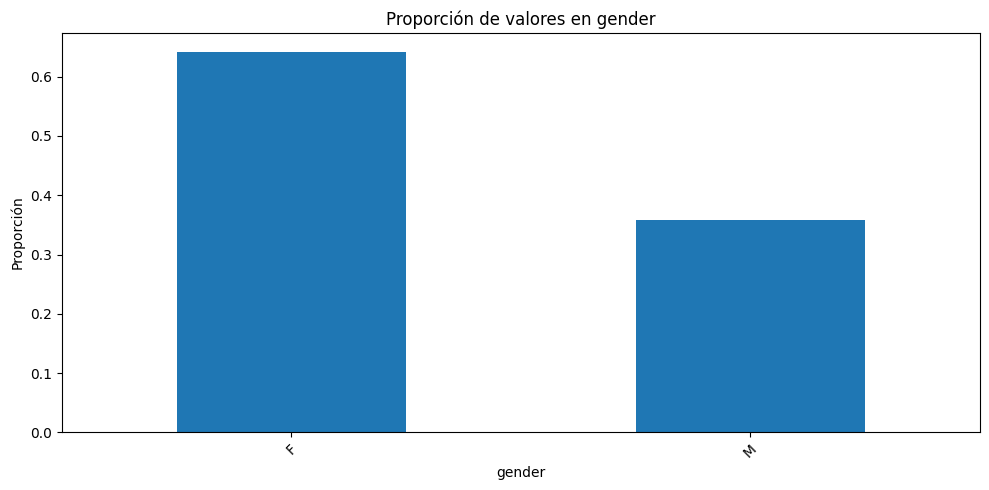

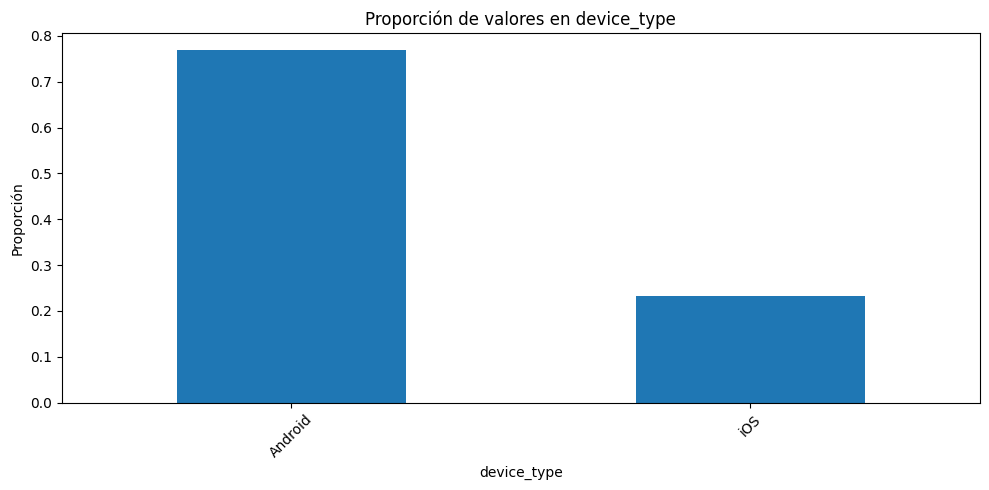

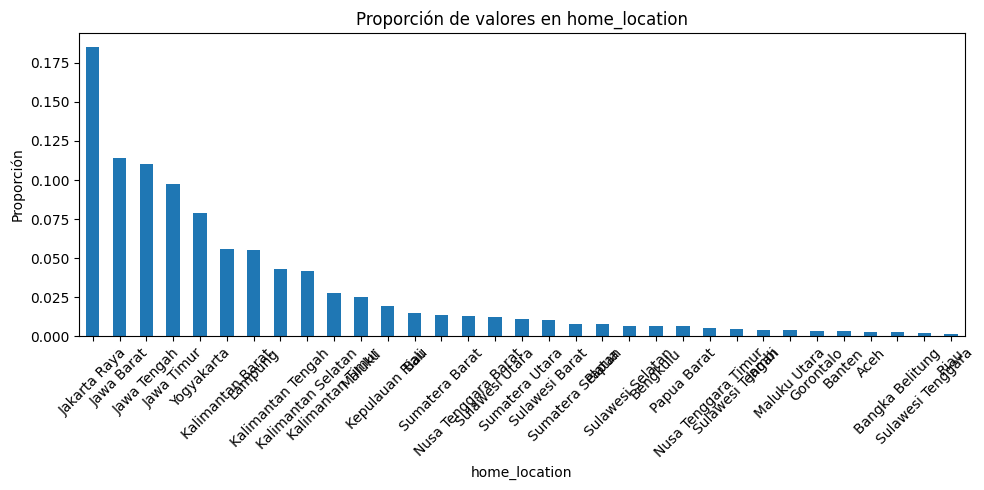

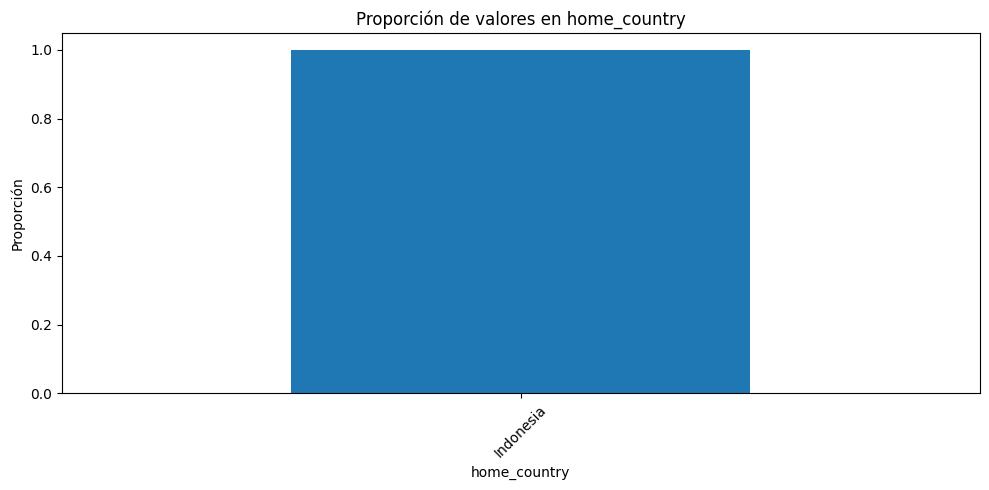

In [ ]:
categorical_columns = [
    'gender',
    'device_type',
    'home_location',
    'home_country'
]


for col in categorical_columns:

    plt.figure(figsize=(10, 5))

    (
        rfm_scaled_customers[col]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .plot(kind='bar')
    )

    plt.title(f'Proporción de valores en {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción')

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
localizaciones=rfm_scaled_customers['home_location'].nunique()
localizaciones

33

En los gráficos de barras de las variables categóricas vemos que hay una predominación de trasacciones hechas por clientes de género femenino frente a masculino. También vemos que la mayoría de las transacciones se realizan desde dispositivos Android.
Por último vemos que hay una alta granularidad de localizaciones diferentes, es decir muchos valores diferentes, y todas las localizaciones son de Indonesia. En concreto podemos ver que tenemos 33 localizaciones diferentes en Indonesia.

En la siguiente pregunta comentaremos con cuales de estas variables nos quedaremos para el estudio.

A conrtinuación, vamos aver como es la distribución de los histogramas de las variables `age` y `tenure_days`.

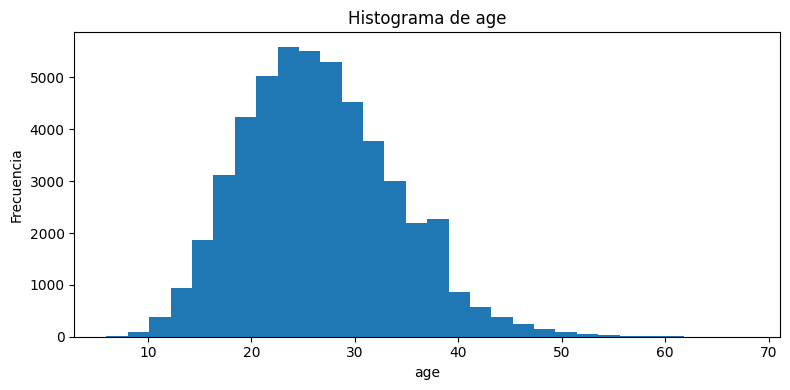

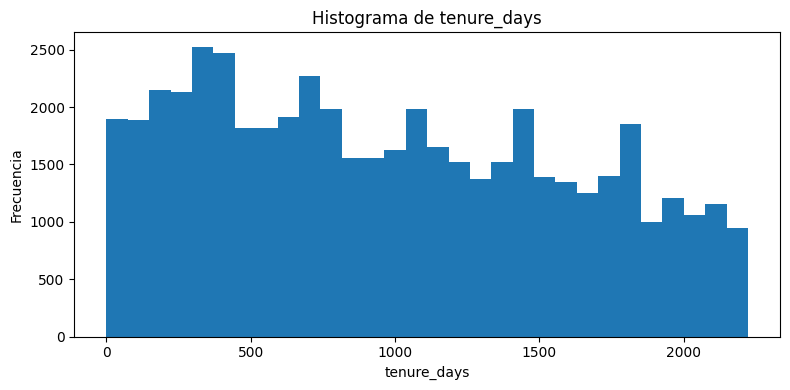

In [ ]:
columns = [
    'age',
    'tenure_days'
]

# Crear gráficos
for col in columns:

    plt.figure(figsize=(8, 4))

    plt.hist(
        rfm_scaled_customers[col],
        bins=30
    )

    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

Vemos que la variable `age` presenta una distribución aproximadamente relativamente cercana a una distribución simétrica, concentrándose la mayor parte de los usuarios entre los 20 y 35 años. Por otro lado, la variable `tenure_days` presenta una distribución bastante más equilibrada y dispersa. En ninguna de las dos observamos colas largas pronunciadas como las presentes en las variables RFM analizadas anteriormente.

Por tanto, en este caso no parece necesario aplicar transformaciones logarítmicas sobre estas variables numéricas, ya que no presentan niveles elevados de asimetría. Sin embargo, sí se aplicará posteriormente un Standard Scaler para normalizar las escalas de las variables y evitar que diferencias en los órdenes de magnitud influyan en el cálculo de distancias durante el proceso de clustering.

In [ ]:
columns = [
    'age',
    'tenure_days'
]


#aplico el escalado
rfm_scaled_customers[columns] = scaler.fit_transform(
    rfm_scaled_customers[columns]
)

rfm_scaled_customers.head()

,customer_id,log_recency,log_frequency,log_monetary,gender,device_type,home_location,home_country,age,tenure_days
0,3,-0.742390,1.566900,1.228804,M,Android,Jakarta Raya,Indonesia,1.304827,0.732060
1,8,-0.243696,-0.004668,0.199389,F,Android,Sulawesi Utara,Indonesia,-0.621648,-0.724131
2,9,-0.361900,-0.119180,-0.039968,F,Android,Jakarta Raya,Indonesia,-1.447281,-0.938609
3,11,0.169027,-1.193513,-1.629484,M,Android,Kalimantan Timur,Indonesia,0.341590,-1.346600
4,15,0.395926,-0.251376,-0.169888,F,Android,Jawa Barat,Indonesia,1.717644,0.088627


#### PREGUNTA 6:
* Justifica qué nuevas variables consideras relevante para la segmentación y, en base a ellas, aplica las técnicas adecuadas de clustering para poder segmentar los datos.

#### RESPUESTA:

En el apartado anterior hemos podido ver que las transacciones pertenecen a un solo país, por lo que vamos a prescindir del campo `home_country` ya que no nos aporta información. Además, el hecho de que todas las localizaciones pertenezcan a Indonesia hace que no tenga mucho sentido conservar el campo de `home_location`, ya que considero que su interpretación resulta limitada sin un conocimiento específico de las distintas regiones representadas en el dataset. Este campo podría servir para observar tendencias entre diferentes zonas del pais, pero para ello considero que es más útil utilizar los campos de altitud y longitud en un clústering geoespacial. Por tanto, vamos a prescindir de esos dos campos en el estudio.

In [ ]:
rfm_scaled_customers= rfm_scaled_customers.drop(columns=['home_location', 'home_country'])

In [ ]:
rfm_scaled_customers.head()

,customer_id,log_recency,log_frequency,log_monetary,gender,device_type,age,tenure_days
0,3,-0.742390,1.566900,1.228804,M,Android,1.304827,0.732060
1,8,-0.243696,-0.004668,0.199389,F,Android,-0.621648,-0.724131
2,9,-0.361900,-0.119180,-0.039968,F,Android,-1.447281,-0.938609
3,11,0.169027,-1.193513,-1.629484,M,Android,0.341590,-1.346600
4,15,0.395926,-0.251376,-0.169888,F,Android,1.717644,0.088627


He estado valorando si quitar o dejar `tenure_days`, ya que presenta cierta relación con variables temporales incluidas en el modelo RFM, especialmente `frequency` y `recency`. Finalmente he decidio conservarla debido a que aporta información complementaria sobre la antigüedad global del cliente dentro de la plataforma, facilitando la identificación de patrones asociados a fidelización, consolidación o crecimiento acelerado dentro del negocio.

Con estas variables quiero construir una segmentación más rica que la basada únicamente en RFM, combinando información transaccional, demográfica, tecnológica y de antigüedad del cliente. Con ello espero facilitar la interpretación posterior de los clústeres y la definición de acciones de negocio más específicas para cada segmento.

In [ ]:
X_cat_num= rfm_scaled_customers.drop(columns=['customer_id'])

Saco los indices de mis columnas categóricas

In [ ]:
categorical_columns = [
    'gender',
    'device_type'
]

cat_idx = [
    X_cat_num.columns.get_loc(col)
    for col in categorical_columns
]

print(cat_idx)

[3, 4]


Usamos la función para sacar los k óptimos para k-prototypes.

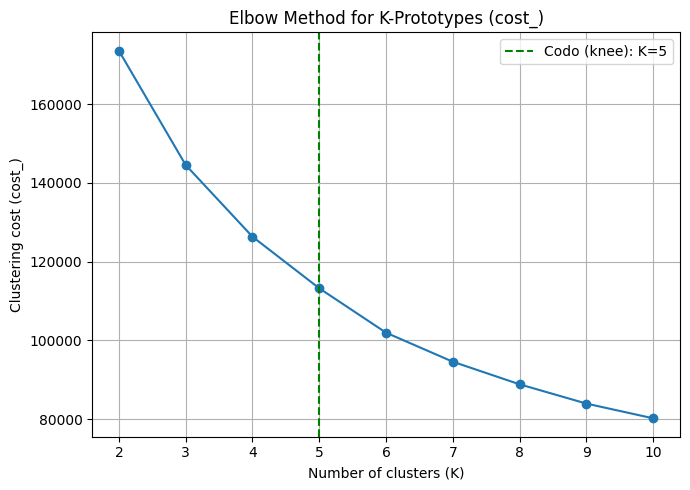

Optimal K by elbow (K-Prototypes): 5


In [ ]:
optimmal_k_results= find_optimal_k_kprototypes_cost(X_cat_num, cat_idx)

Entrenamos nuestro modelos de clustering para k=5. Con "Huang" indicamos que es el método utilizado para inicializar los centroides categóricos y n_init=10 indica que el algoritmo se ejecutará 10 veces con diferentes inicializaciones aleatorias, conservando finalmente la solución con menor coste.

In [ ]:
kproto = KPrototypes(
    n_clusters=optimmal_k_results["optimal_k_elbow"],
    init="Huang",
    n_init=10,
    random_state=42
)

kproto.fit(X_cat_num.values, categorical=cat_idx)

,n_clusters,5
,max_iter,100
,num_dissim,<function euc...001F3B8113320>
,cat_dissim,<function mat...001F3B8113110>
,init,'Huang'
,n_init,10
,gamma,np.float64(0.5)
,verbose,0
,random_state,42
,n_jobs,1


In [ ]:
df_cluster_num_cat_scaled = X_cat_num.copy()
df_cluster_num_cat_scaled['proto_labels'] = kproto.labels_

In [ ]:
df_cluster_num_cat_scaled

,log_recency,log_frequency,log_monetary,gender,device_type,age,tenure_days,proto_labels
0,-0.742390,1.566900,1.228804,M,Android,1.304827,0.732060,2
1,-0.243696,-0.004668,0.199389,F,Android,-0.621648,-0.724131,0
2,-0.361900,-0.119180,-0.039968,F,Android,-1.447281,-0.938609,0
3,0.169027,-1.193513,-1.629484,M,Android,0.341590,-1.346600,4
4,0.395926,-0.251376,-0.169888,F,Android,1.717644,0.088627,3
...,...,...,...,...,...,...,...,...
50237,-0.332676,0.411689,0.266891,F,Android,1.580038,-0.356455,3
50238,-2.204964,1.723254,1.479394,F,Android,-1.309675,-0.432248,0
50239,1.301815,-1.193513,-1.545679,M,iOS,-1.172070,-0.250022,4
50240,0.329796,0.096339,0.530759,F,Android,-2.548124,0.820754,1


In [ ]:
label = "proto_labels"
numeric_cols = ["log_recency", "log_frequency", "log_monetary"]

# Polar medias por cluster usando variables escaladas
polar = (df_cluster_num_cat_scaled
         .groupby(label)[numeric_cols]
         .mean()
         .reset_index()
         .melt(id_vars=[label], var_name="variable", value_name="value"))

fig_k_prot_4 = px.line_polar(
    polar,
    r="value",
    theta="variable",
    color=label,
    line_close=True,
    height=800,
    width=600,
)

fig_k_prot_4.show()
fig_k_prot_4.write_image("fig_k_prot_4.png")

In [ ]:
rfm_og_prototypes_id.head()

,customer_id,recency,frequency,monetary,gender,device_type,home_location,home_country,age,tenure_days
0,3,36,49,20891374,M,Android,Jakarta Raya,Indonesia,36,1436
1,8,78,7,3898561,F,Android,Sulawesi Utara,Indonesia,22,533
2,9,65,6,2638665,F,Android,Jakarta Raya,Indonesia,16,400
3,11,147,1,197533,M,Android,Kalimantan Timur,Indonesia,29,147
4,15,208,5,2134870,F,Android,Jawa Barat,Indonesia,39,1037


In [ ]:
categorical_columns= ['gender', 'device_type', 'home_location', 'home_country']
rfm_og_prototypes=rfm_og_prototypes_id.drop(columns=['customer_id'])
df_cluster_num = rfm_og_prototypes.copy()
df_cluster_num = df_cluster_num.drop(columns=categorical_columns)
df_cluster_num[label] = df_cluster_num_cat_scaled[label].values
df_cluster_cat = rfm_og_prototypes[['gender', 'device_type']].copy()
df_cluster_cat[label] = df_cluster_num_cat_scaled[label].values

# Nombres de columnas numéricas
rfm_og_prototypes_num_cols = df_cluster_num.drop(columns=[label]).columns.tolist()

# Resumen: medias con variables originales
cluster_summary = df_cluster_num.groupby(label)[rfm_og_prototypes_num_cols].mean().round(2)

cluster_summary["Genders"] = (
    df_cluster_cat.groupby(label)["gender"]
    .apply(lambda s: ", ".join([f"{c} ({n}, {n/len(s)*100:.1f}%)" for c, n in s.value_counts().head(5).items()]))
)

cluster_summary["Devices"] = (
    df_cluster_cat.groupby(label)["device_type"]
    .apply(lambda s: ", ".join([f"{c} ({n}, {n/len(s)*100:.1f}%)" for c, n in s.value_counts().head(2).items()]))
)

# Recuento por cluster (importante: sort_index para que coincida con el groupby)
cluster_summary["Count"] = df_cluster_num[label].value_counts().sort_index()

print("Summary:")
display(cluster_summary)

Summary:


,recency,frequency,monetary,age,tenure_days,Genders,Devices,Count
proto_labels,,,,,,,,
0,39.11,16.02,8918892.00,24.28,462.29,"F (7118, 65.2%), M (3802, 34.8%)","Android (8372, 76.7%), iOS (2548, 23.3%)",10920
1,856.71,2.98,1542442.16,24.84,1542.78,"F (7141, 64.2%), M (3985, 35.8%)","Android (8548, 76.8%), iOS (2578, 23.2%)",11126
2,56.02,50.70,28119603.03,25.89,1526.11,"F (6678, 63.1%), M (3910, 36.9%)","Android (8146, 76.9%), iOS (2442, 23.1%)",10588
3,215.71,7.29,3964230.15,37.16,903.80,"F (4338, 63.9%), M (2447, 36.1%)","Android (5255, 77.5%), iOS (1530, 22.5%)",6785
4,285.26,2.00,906779.41,24.45,446.81,"F (6978, 64.5%), M (3845, 35.5%)","Android (8274, 76.4%), iOS (2549, 23.6%)",10823


#### PREGUNTA 7:
* ¿Qué insights adicionales se derivan del uso de estas variables extra? ¿Qué acciones concretas recomendarías sobre los clientes?

#### RESPUESTA:



In [ ]:
fig_k_prot_4.show()
print("Resumen:")
display(cluster_summary)


Resumen:


,recency,frequency,monetary,age,tenure_days,Genders,Devices,Count
proto_labels,,,,,,,,
0,39.11,16.02,8918892.00,24.28,462.29,"F (7118, 65.2%), M (3802, 34.8%)","Android (8372, 76.7%), iOS (2548, 23.3%)",10920
1,856.71,2.98,1542442.16,24.84,1542.78,"F (7141, 64.2%), M (3985, 35.8%)","Android (8548, 76.8%), iOS (2578, 23.2%)",11126
2,56.02,50.70,28119603.03,25.89,1526.11,"F (6678, 63.1%), M (3910, 36.9%)","Android (8146, 76.9%), iOS (2442, 23.1%)",10588
3,215.71,7.29,3964230.15,37.16,903.80,"F (4338, 63.9%), M (2447, 36.1%)","Android (5255, 77.5%), iOS (1530, 22.5%)",6785
4,285.26,2.00,906779.41,24.45,446.81,"F (6978, 64.5%), M (3845, 35.5%)","Android (8274, 76.4%), iOS (2549, 23.6%)",10823


Como podemos ver en el gráfico, sí que se han modificado los grupos respecto a cuando solo teníamos las variables RFM. De hecho se ha creado un grupo más. Sin embargo, podemos ver en el resumen que las variables `gender` y `device_type` presentan una capacidad discriminativa relativamente baja dentro del proceso de clustering, ya que sus distribuciones son muy similares entre los distintos grupos generados.

Algo similar ocurre con la edad, que solo es diferencial respecto al resto en uno de los grupos. En concreto, el clúster 3 presenta clientes con una media de edad unos 12 años superior a la media de edad de los clientes del resto de grupos. Esto podría indicar la existencia de un perfil de usuarios de mayor edad con patrones de compra diferenciados respecto al resto de clientes de la plataforma. Al fijarnos en otros campos como `tenure_days`podríamos decir que estos clientes presentan además una antigüedad intermedia dentro de la plataforma, junto con una frecuencia y gasto moderados, lo que podría representar usuarios relativamente estables pero con hábitos de compra más moderados.

Por otro lado, la variable `tenure_days` sí parece aportar información más relevante dentro del proceso de segmentación. Podemos observar que el clúster 2, correspondiente a los clientes de mayor valor económico y mayor frecuencia de compra, y con una antigüedad muy elevada dentro de la plataforma. Podemos entonces decir que los clientes más rentables suelen corresponder a usuarios consolidados y fidelizados en el tiempo. El clúster 1 también presenta valores altos de tenure_days, pero con recencia muy elevada y frecuencia baja, lo que ppuede indicar antiguos clientes actualmente inactivos.

Vemos también que los clústeres 0 y 4 presentan valores de antigüedad considerablemente menores. Sin embargo, son distintos entre sí. Mientras que el clúster 0 presenta una frecuencia relativamente elevada y un gasto significativo, el clúster 4 agrupa clientes recientes con poca actividad y bajo gasto acumulado. Esto podría indicar que el clúster 0 representa clientes relativamente nuevos con una rápida consolidación dentro de la plataforma y que el clúster 4 estaría formado por usuarios recientes que todavía no han desarrollado hábitos de compra.

Desde una perspectiva de negocio, sobre el clúster 2 podrían aplicarse estrategias premium y de fidelización avanzada orientadas a maximizar la retención de los clientes más valiosos. En el clúster 1 haríamos campañas de reactivación y recuperación de clientes antiguos. Para el clúster 0 podrían impulsarse estrategias destinadas a consolidar la fidelización de clientes con alto potencial de crecimiento. En cambio, en el clúster 4 resultarían especialmente interesantes campañas de onboarding, promociones iniciales o sistemas de recomendación personalizados orientados a capturar eso clientes. Teniendo en cuenta la diferencia en la media de edad del clúster 3 podríamos hacer campañas adaptadas a esa franja de edad, con recomendaciones de productos o estrategias de comunicación más específicas para ese segmento.

## 5. Clustering Geográfico con DBSCAN

#### PREGUNTA 8:
* Analiza los datos de geolocalización de los lugares de residencia y realiza una segmentación de clientes en base a dicha información utilizando DBSCAN

#### RESPUESTA:

Como nos piden analizar los datos de geolocalización para realizar una segmentación de clientes vamos a partir de las variables geoespaciales que habíamos guardado previamente en `coord_geo_id`.

In [ ]:
coord_geo_id.head()

,customer_id,home_location_lat,home_location_long
0,2870,-1.043345,101.360523
1,8193,-6.212489,106.818850
2,7279,-8.631607,116.428436
3,88813,1.299332,115.774934
4,82542,-2.980807,114.924675


Normalmente el DBSCAN geográfico se realiza empleando la métrica de Haversine que es una ecuación que calcula la distancia más corta entre dos puntos sobre la superficie de una esfera, conociendo sus coordenadas de latitud y longitud. Se utiliza en navegación y geografía considerando que la forma de la Tierra se puede aproximar a una esfera. Es necesario que la longitud y la latitud se introduzcan en radianes.

In [ ]:
coord_geo = coord_geo_id[
    ['home_location_lat', 'home_location_long']
].copy()
coord_geo = coord_geo.to_numpy()
coords_geo_rad = np.radians(coord_geo)

In [ ]:
#fijamos la distancia máxima en la que consideramos que dos puntos son vecinos
max_dist_km = 50

#Definimos elñ radio terrestre para pasar a radianes el max_dist
earth_radius_km = 6371.0

#Pasamos max_dist a radianes
max_dist_rad = max_dist_km / earth_radius_km

dbscan = DBSCAN(
    eps=max_dist_rad,
    min_samples=20,
    metric='haversine'
)

coord_geo_id['geo_cluster'] = dbscan.fit_predict(coords_geo_rad)

Vamos a ver los distintos grupos que obtenemos y el número de puntos en cada uno ordenados de mayor a menor:

In [ ]:
coord_geo_id['geo_cluster'].value_counts()

geo_cluster
 0     73366
 1     16650
 2      3971
 5      1468
 6       637
 8       424
 13      399
-1       327
 11      275
 17      275
 3       253
 15      171
 9       164
 16      151
 20      128
 7       127
 14      127
 29      125
 22      117
 18       88
 4        87
 26       81
 27       81
 23       60
 31       59
 28       53
 32       50
 10       40
 12       39
 25       35
 19       34
 21       29
 24       28
 30       25
 34       20
 33       20
 35       16
Name: count, dtype: int64

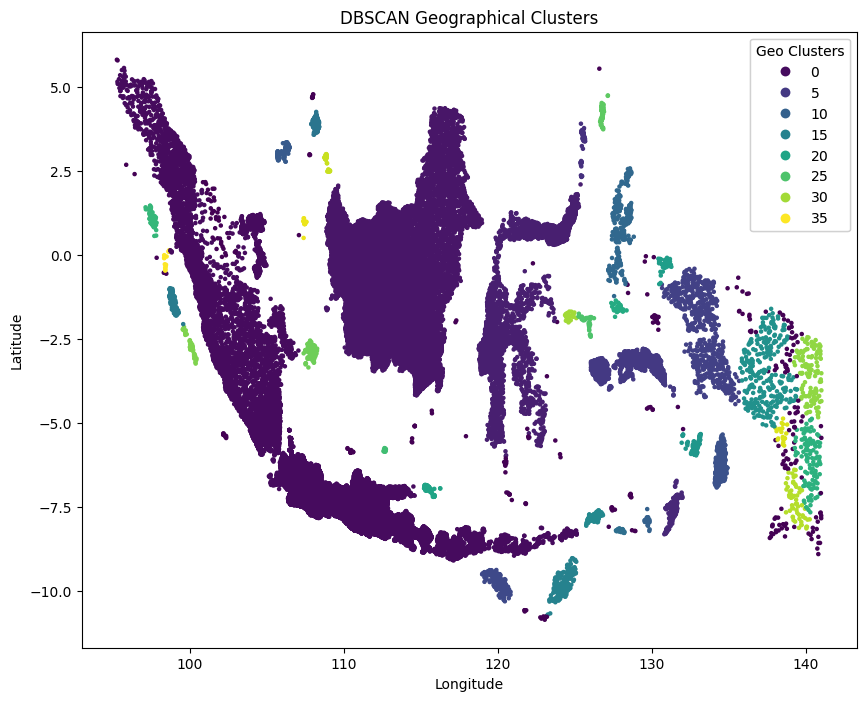

In [ ]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    coord_geo_id['home_location_long'],
    coord_geo_id['home_location_lat'],
    c=coord_geo_id['geo_cluster'],
    s=5
)

# Leyenda automática
legend = plt.legend(
    *scatter.legend_elements(),
    title="Geo Clusters"
)

plt.gca().add_artist(legend)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Geographical Clusters")

plt.show()

Vemos que la reprsentación optenida guarda gran similitud con el mapa de Indonesia, lo cual tiene sentido pues todas las transacciones procedian de diferentes partes del país.

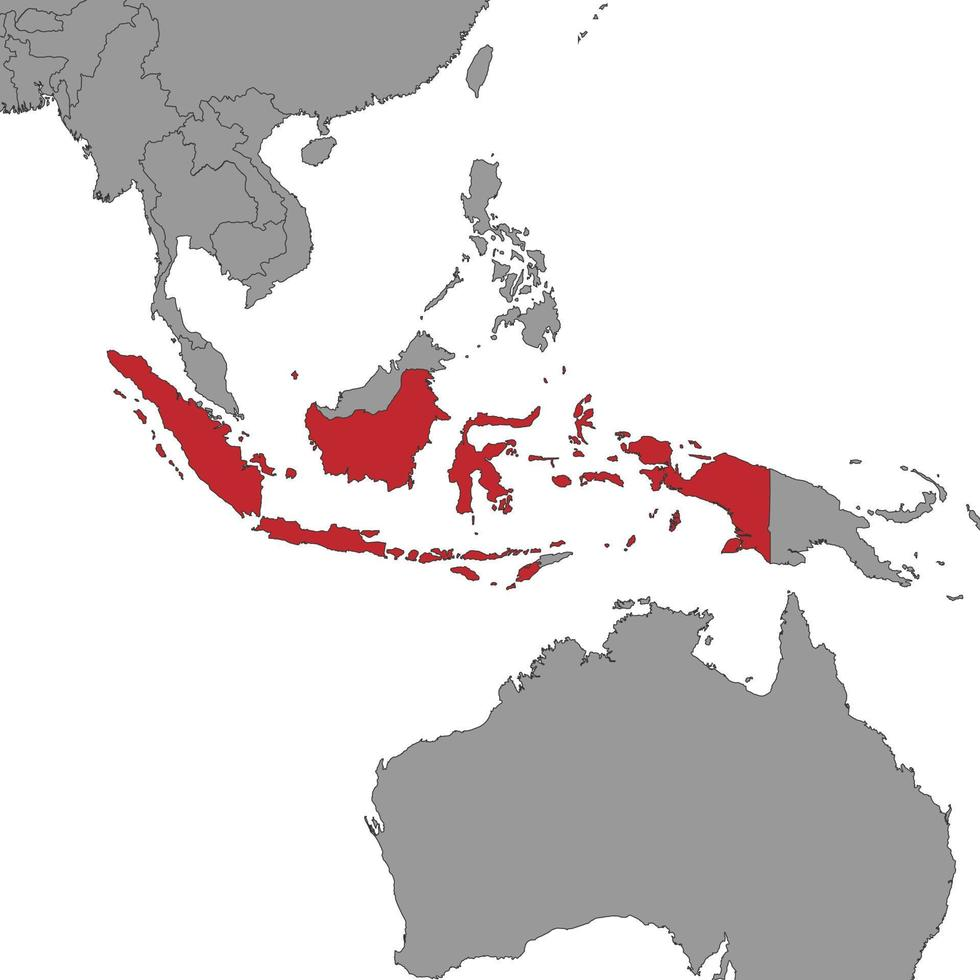
Aunque podemos apreciar que la representación gráfica está deformada respecto al mapa real. Esto se debe a que las coordenadas de latitud y longitud están siendo representadas directamente sobre un plano cartesiano sin aplicar una proyección geográfica específica, lo que introduce distorsiones espaciales

Fijando la máxima distancia entre vecinos como 50 km hemos conseguido una segnmentación muy similar a los diferentes valores de localización presentes en la tabla dse clientes, por tanto el algoritmo no está descubriendo estructuras espaciales significativamente diferentes a las ya representadas en los datos originales.

Vamos a probar fijando una `max_dist` mayor para tener una segmentación en menos grupos. También vamos a modificar `min_samples`, que determina cuántos clientes deben existir cerca unos de otros para formar un grupo. Tras varias pruebas he encontrado una segmentación que puede ser interesante:

In [ ]:
#fijamos la distancia máxima en la que consideramos que dos puntos son vecinos
max_dist_km = 124.7

#Definimos elñ radio terrestre para pasar a radianes el max_dist
earth_radius_km = 6371.0

#Pasamos max_dist a radianes
max_dist_rad = max_dist_km / earth_radius_km

dbscan = DBSCAN(
    eps=max_dist_rad,
    min_samples=50,
    metric='haversine'
)
coord_geo_id_2=coord_geo_id.copy()
coord_geo_id_2['geo_cluster'] = dbscan.fit_predict(coords_geo_rad)

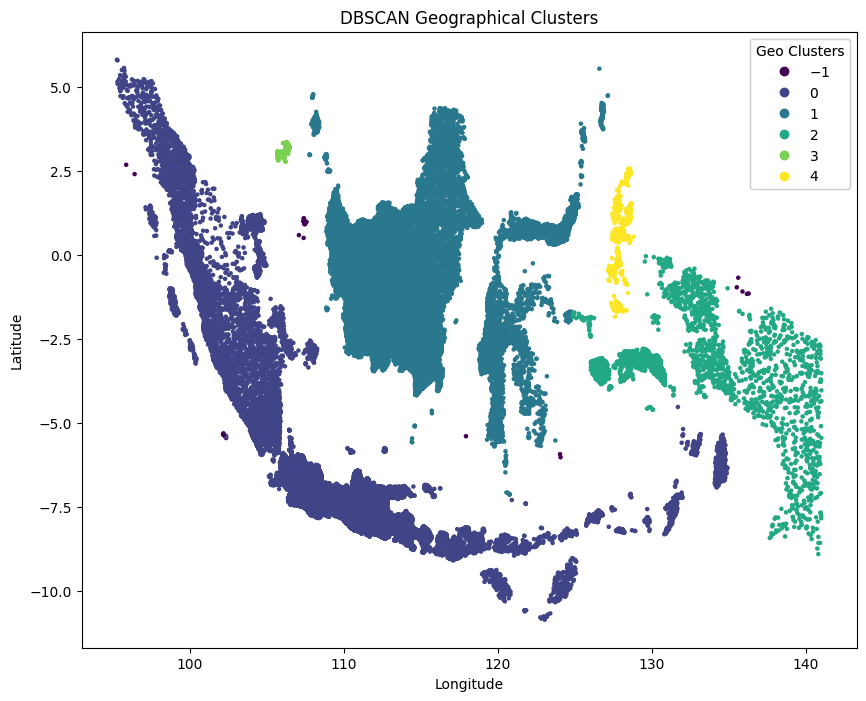

In [ ]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    coord_geo_id_2['home_location_long'],
    coord_geo_id_2['home_location_lat'],
    c=coord_geo_id_2['geo_cluster'],
    s=5
)

# Leyenda automática
legend = plt.legend(
    *scatter.legend_elements(),
    title="Geo Clusters"
)

plt.gca().add_artist(legend)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Geographical Clusters")

plt.show()

In [ ]:
coord_geo_id_2['geo_cluster'].value_counts()

geo_cluster
 0    75263
 1    21306
 2     2924
 4      306
 3      164
-1       37
Name: count, dtype: int64

#### PREGUNTA 9:
* ¿Qué insights se derivan de esta segmentación y qué acciones concretas propondrías?

#### RESPUESTA:





In [ ]:
coord_geo_id_2['geo_cluster'].value_counts()

geo_cluster
 0    75263
 1    21306
 2     2924
 4      306
 3      164
-1       37
Name: count, dtype: int64

In [ ]:
#Calculo la proporción de cada grupo respecto al total de clientes.
coord_geo_id_2_prop=coord_geo_id_2['geo_cluster'].value_counts(normalize=True) * 100
coord_geo_id_2_prop

geo_cluster
 0    75.263
 1    21.306
 2     2.924
 4     0.306
 3     0.164
-1     0.037
Name: proportion, dtype: float64

Voy a representar esas proporciones en la leyenda del mapa formado.

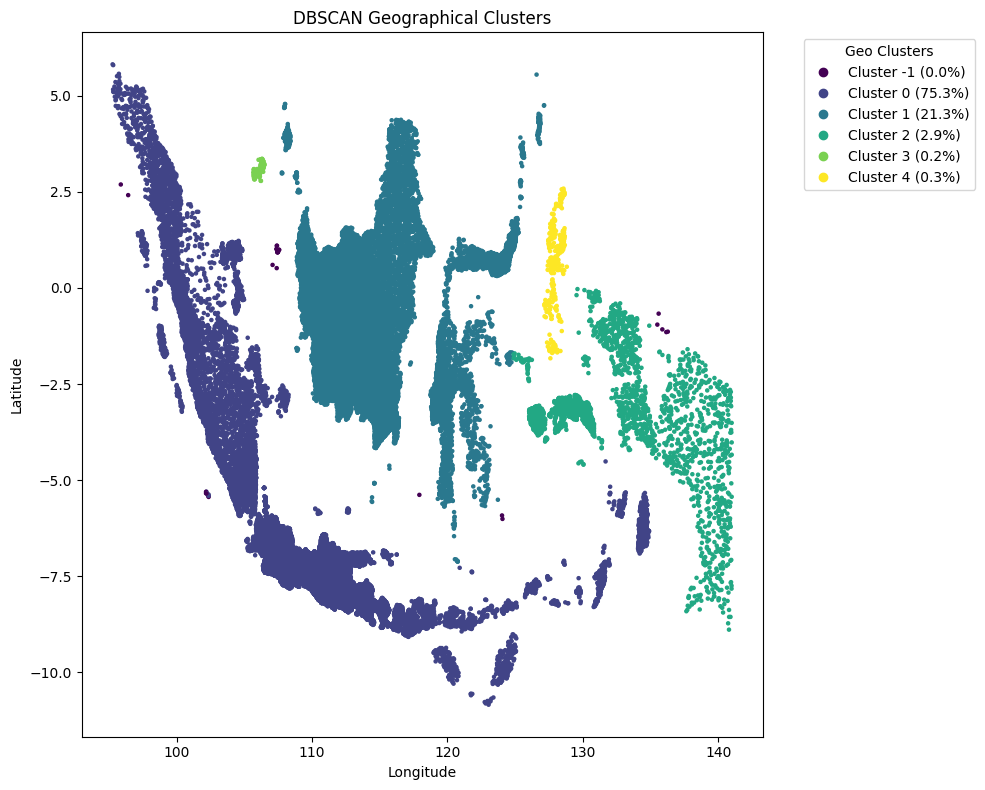

In [ ]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    coord_geo_id_2['home_location_long'],
    coord_geo_id_2['home_location_lat'],
    c=coord_geo_id_2['geo_cluster'],
    s=5
)

#calculo las proporciones
cluster_props = (
    coord_geo_id_2['geo_cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

#fijo que va a contener mi leyenda
handles, labels = scatter.legend_elements()

new_labels = []

for lbl in labels:

    #para devolver etiquetas con formato interno de matplotlib
    clean_lbl = (
        lbl
        .replace('$\\mathdefault{', '')
        .replace('}$', '')
        .replace('−', '-')
    )

    cluster_id = int(float(clean_lbl))

    perc = cluster_props.loc[cluster_id]

    new_labels.append(
        f"Cluster {cluster_id} ({perc:.1f}%)"
    )

#creo la leyenda
legend = plt.legend(
    handles,
    new_labels,
    title="Geo Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Geographical Clusters")

plt.tight_layout()
plt.show()

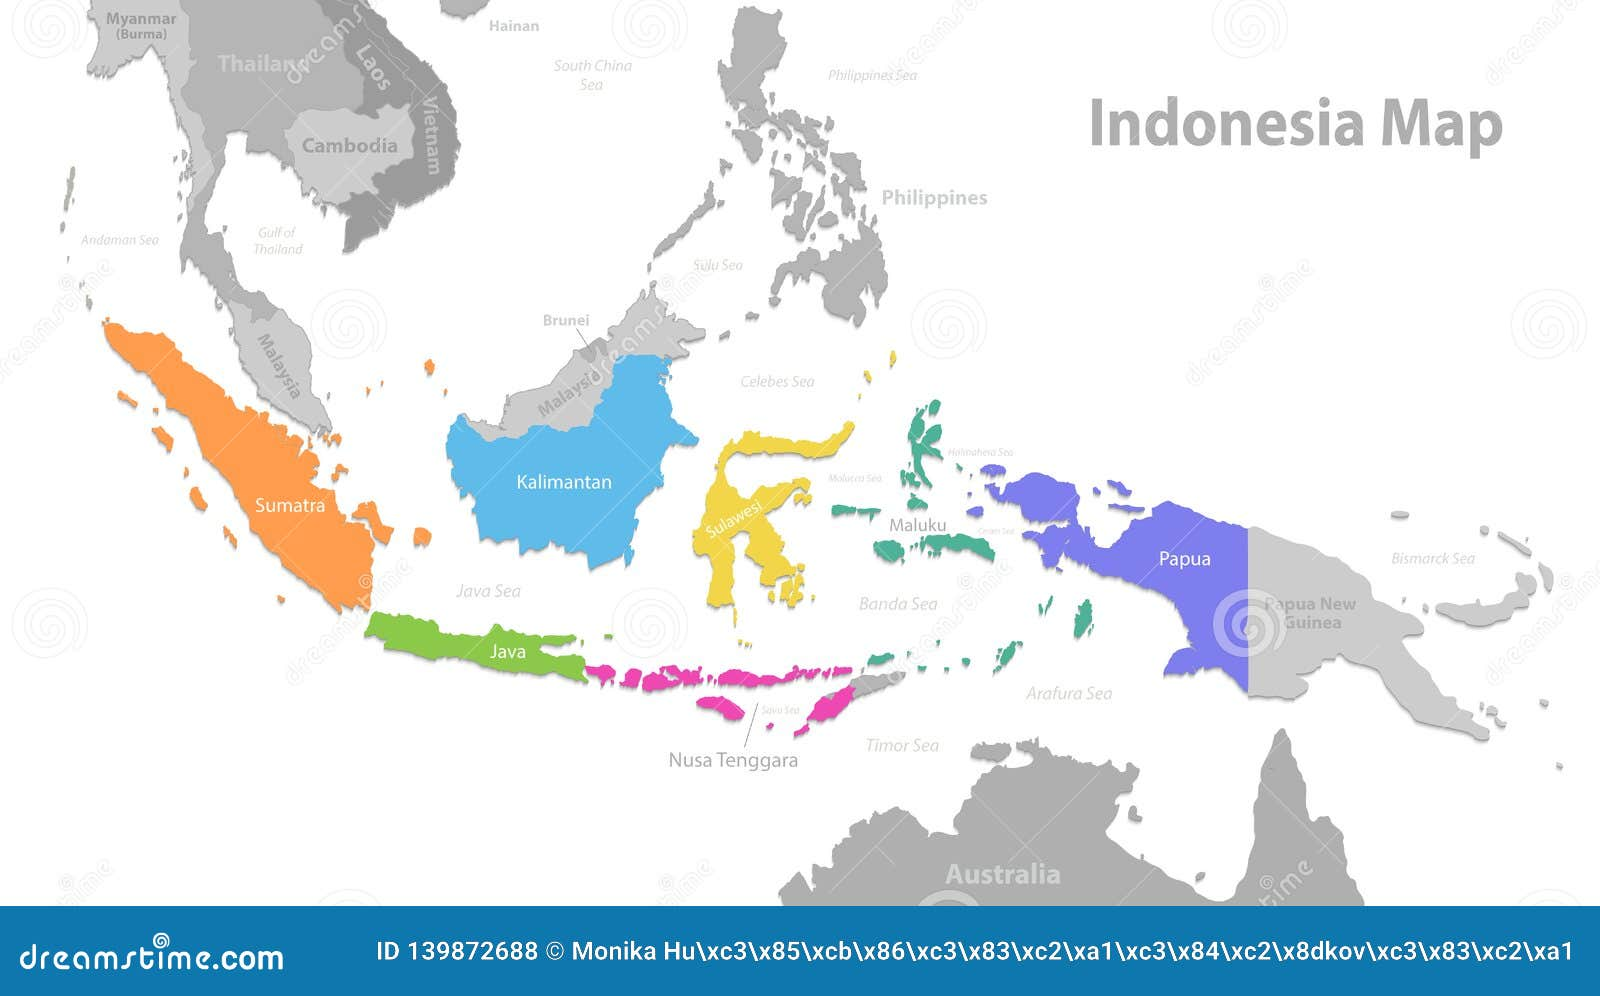

Vemos que el mayor porcentaje de clientes procede de Sumatra, Java, Nussa Tengara y las islas de su influencia. La segunda región con mayor porcentaje de clientes corresponde con Kalinmantan y Sulawesi. En mucha menor proporción tenemos clientes de Papua y Maluku. Los porcentajes mas pequeñós cooresponden, en orden, al archipíelago más al norte de Maluku y a islas aisladas entre otras regiones.

Por tanto, Estos resultados reflejan una distribución geográfica muy desigual de los clientes dentro de Indonesia. Se concentran más en regiones densamente pobladas como Java y Sumatra. Esto sugiere que gran parte de la actividad comercial de la plataforma se concentra en los principales núcleos urbanos y regiones con mayor desarrollo económico e infraestructural del país.

Por otro lado, regiones como Papua, Maluku o pequeños archipiélagos presentan un porcentaje considerablemente menor de clientes, lo que podría deberse a factores como menor densidad de población, menor penetración tecnológica, limitaciones logísticas o menor alcance comercial de la plataforma en dichas zonas.

Desde una perspectiva de negocio, podríamos utilizar esto para adaptar estrategias comerciales y logísticas según cada región. En las zonas con mayor concentración de clientes podrían potenciarse campañas de fidelización, promociones específicas o mejoras logísticas orientadas a maximizar la recurrencia y el volumen de ventas. Por el contrario, en regiones con baja presencia de clientes podrían desarrollarse estrategias de expansión y captación, como campañas publicitarias regionales, o incluso invertir en mejorar la logística y la infraestructura de envíos en esas zonas. Por tanto, esta segmentación espacial también podríamos utilizarla para optimizar costes logísticos, identificar regiones prioritarias para futuras inversiones o adaptar campañas comerciales al consumo regional.

#### DECLARACIÓN DE USO DE IA

Durante la elaboración de esta tarea se han utilizado herramientas de IA, en concreto ChatGPT y Gemini.

ChatGPT se ha usado de manera asistencial para comentar dudas sobre los planteamientos realizados, ayudar con la redacción y valorar enfoques. En menor medida también se ha empleado para la elaboración de código y corrección bugs.

Gemini se ha usado fundamentalmente en el entorno de Collab para el autocompletado de código y la corrección de bugs.